In [18]:
import os
import scipy.stats 
from scipy.stats import norm
from statsmodels.stats.multitest import multipletests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx

# Setup

### Config

In [19]:
# ============================================================
# CONFIG
# ============================================================
# All paths, group names, and output identifiers are defined
# here.
# DATASET TOGGLE: set to "all" or "group1" to switch between
# the all-genes and Group I gene subsets. All downstream
# cells adapt automatically to the selected dataset.
# ============================================================

from pathlib import Path

DATASET = "all"    # Options: "all" | "group1"

# --- Shared output directory ---
# Must match OUTPUT_DIR used in the modeling notebook
OUTPUT_DIR = Path("../brassica_outputs/model_outputs")

# --- Network-specific output directory ---
# Individual network plots, heatmaps, and edge tables are
# saved here. Created automatically if it does not exist.
# Kept local and regenerable — not tracked in git (see .gitignore).
NETWORK_DIR = Path("../brassica_outputs/network_output")
os.makedirs(NETWORK_DIR, exist_ok=True)

if DATASET == "all":
    GROUPS      = [
        "LF-MF1", 
        "LF-MF2", 
        "MF1-MF2"
    ]
    GROUP_LABELS = {
        "LF-MF1": "LF-MF1", 
        "LF-MF2": "LF-MF2", 
        "MF1-MF2": "MF1-MF2"
    }
    PREFIXES     = {
        "LF-MF1": "lf_mf1_all", 
        "LF-MF2": "lf_mf2_all", 
        "MF1-MF2": "mf1_mf2_all"
    }
    EXPECTED_FEATURES = 45
    CUSTOM_THICKNESS  = {
        "LF-MF1": 9.0, 
        "LF-MF2": 10.0, 
        "MF1-MF2": 6.0
    }
    # SIG_EDGE_COUNTS: Reference counts from the exploratory t-test + BH FDR approach 
    # (superseded by the permutation method actually used in the final networks). Shown only
    # as retention-curve context — not expected to match final network edge counts.
    SIG_EDGE_COUNTS   = {
        "LF-MF1": 128, 
        "LF-MF2": 136, 
        "MF1-MF2": 91
    }
    COMBINED_SUFFIX   = "all"

elif DATASET == "group1":
    GROUPS      = [
        "LF-MF1_g1", 
        "LF-MF2_g1", 
        "MF1-MF2_g1"
    ]
    GROUP_LABELS = {
        "LF-MF1_g1": "LF-MF1 Group1", 
        "LF-MF2_g1": "LF-MF2 Group1", 
        "MF1-MF2_g1": "MF1-MF2 Group1"
    }
    PREFIXES     = {
        "LF-MF1_g1": "lf_mf1_groupI", 
        "LF-MF2_g1": "lf_mf2_groupI",
        "MF1-MF2_g1": "mf1_mf2_groupI",
    }  
    EXPECTED_FEATURES = 44
    CUSTOM_THICKNESS  = {
        "LF-MF1_g1": 8.0, 
        "LF-MF2_g1": 8.0, 
        "MF1-MF2_g1": 8.0
    }
    # SIG_EDGE_COUNTS: Reference counts from the exploratory t-test + BH FDR approach 
    # (superseded by the permutation method actually used in the final networks). Shown only
    # as retention-curve context — not expected to match final network edge counts.
    SIG_EDGE_COUNTS   = {
        "LF-MF1_g1": 118, 
        "LF-MF2_g1": 127, 
        "MF1-MF2_g1": 88
    }
    COMBINED_SUFFIX   = "groupI"

else:
    raise ValueError(f"Unknown DATASET: '{DATASET}'. Expected 'all' or 'group1'.")

GROUP_COLORS = dict(zip(GROUPS, ["#1f77b4", "#ff7f0e", "#2ca02c"]))
NPZ_PATHS    = {group: os.path.join(OUTPUT_DIR, f"{PREFIXES[group]}_shap_by_label.npz") for group in GROUPS}

# --- Validate all files exist before proceeding ---
missing_files = [path for path in NPZ_PATHS.values() if not os.path.exists(path)]
if missing_files:
    raise FileNotFoundError(
        f"The following .npz files were not found. Run the modeling notebook "
        f"for each group before proceeding:\n" +
        "\n".join(missing_files)
    )
else:
    print("All .npz files found:")
    for group, path in NPZ_PATHS.items():
        print(f"  {group}: {path}")

All .npz files found:
  LF-MF1: /blue/meixiazhao/laylaaschuster/brapaGDM/final_models/model_outputs/lf_mf1_all_shap_by_label.npz
  LF-MF2: /blue/meixiazhao/laylaaschuster/brapaGDM/final_models/model_outputs/lf_mf2_all_shap_by_label.npz
  MF1-MF2: /blue/meixiazhao/laylaaschuster/brapaGDM/final_models/model_outputs/mf1_mf2_all_shap_by_label.npz


### Load Data

In [20]:
# ==========================================================================
# LOAD DATA
# ==========================================================================
# Loads SHAP arrays and feature names from .npz files
# produced by the modeling notebook. All three pairwise groups
# are loaded into a single dict for clean downstream access.
#
# Keys available per group after loading:
#   shap_data[group]["shap_all"]      — full SHAP array (all samples)
#   shap_data[group]["shap_label0"]   — SHAP for label=0 (dominant subgenome)
#   shap_data[group]["shap_label1"]   — SHAP for label=1 (non-dominant subgenome)
#   shap_data[group]["feature_names"] — feature name array
#   shap_data[group]["counts"]        — [n_label0, n_label1]
#   shap_data[group]["shap_interaction_all"]    — Shapley interaction values
#                                                  (all samples),
#                                                  shape (n_samples, n_features,
#                                                         n_features)
#   shap_data[group]["true_labels"]             — label vector aligned to
#                                                  shap_all rows.
#                                                  Label encoding is
#                                                  group-specific:
#                                                    LF-MF1:  0=LF, 1=MF1
#                                                    LF-MF2:  0=LF, 1=MF2
#                                                    MF1-MF2: 0=MF1, 1=MF2
#   shap_data[group]["shap_interaction_label0"] — interaction values for
#                                                  dominant subgenome only
#   shap_data[group]["shap_interaction_label1"] — interaction values for
#                                                  non-dominant subgenome only
# ==========================================================================

shap_data = {}

for group in GROUPS:
    path = NPZ_PATHS[group]
    data = np.load(path, allow_pickle=False)

    shap_data[group] = {
        "shap_all"             : data["shap_all"].astype(np.float64),
        "shap_label0"          : data["shap_label0"].astype(np.float64),
        "shap_label1"          : data["shap_label1"].astype(np.float64),
        "shap_interaction_all" : data["shap_interaction_all"].astype(np.float64),
        "true_labels"          : data["true_labels"].astype(np.int8),
        "feature_names"        : data["feature_names"].tolist(),
        "counts"               : data["counts"],
    }

    print(f"Group {group}:")
    print(f"  shap_all    : {shap_data[group]['shap_all'].shape}")
    print(f"  shap_label0 : {shap_data[group]['shap_label0'].shape}")
    print(f"  shap_label1 : {shap_data[group]['shap_label1'].shape}")
    print(f"  n_features  : {len(shap_data[group]['feature_names'])}")
    print(f"  counts      : label0={shap_data[group]['counts'][0]}, "
          f"label1={shap_data[group]['counts'][1]}")
    print(f"  shap_interaction_all: {shap_data[group]['shap_interaction_all'].shape}")

    # --- Symmetry check ---
    # Shapley interaction values are symmetric by definition (φ_jk = φ_kj).
    # Numerical precision can introduce small asymmetries; tolerance of 1e-4
    # is appropriate for float32 data cast to float64.
    interact = shap_data[group]["shap_interaction_all"]
    max_asymmetry = np.abs(interact - interact.transpose(0, 2, 1)).max()
    assert max_asymmetry < 1e-4, (
        f"Group {group}: interaction matrix asymmetry {max_asymmetry:.2e} "
        f"exceeds tolerance. Check shap_interaction_values() output."
    )
    print(f"  symmetry check passed (max asymmetry: {max_asymmetry:.2e})")
    print()

    # --- Split interaction array by label ---
    # Biological motivation: dominant and non-dominant subgenomes in Brassica
    # rapa may show asymmetric feature interactions — averaging across labels
    # could suppress subgenome-specific signal. Label encoding is
    # group-specific (see header above).
    _labels = shap_data[group]["true_labels"]
    _mask0  = (_labels == 0)
    _mask1  = (_labels == 1)
    shap_data[group]["shap_interaction_label0"] = (
        shap_data[group]["shap_interaction_all"][_mask0]
    )
    shap_data[group]["shap_interaction_label1"] = (
        shap_data[group]["shap_interaction_all"][_mask1]
    )
    print(f"  shap_interaction_label0: "
          f"{shap_data[group]['shap_interaction_label0'].shape}")
    print(f"  shap_interaction_label1: "
          f"{shap_data[group]['shap_interaction_label1'].shape}")

# --- Validate expected feature counts ---
# EXPECTED_FEATURES is set in the config cell:
#   45 for "all"  (includes 'location')
#   44 for "group1" (excludes 'location')
# If this check fails, the modeling notebook was run with a different
# preprocessing file than expected.
for group in GROUPS:
    n = len(shap_data[group]["feature_names"])
    if n != EXPECTED_FEATURES:
        raise ValueError(
            f"Group {group} has {n} features, expected {EXPECTED_FEATURES}. "
            f"Check that the correct preprocessing file was used."
        )

print(f"Feature count validation passed: all groups have {EXPECTED_FEATURES} features.")

# --- Validate feature names are identical across all groups ---
# All three pairwise groups were preprocessed with the same pipeline
# and should share an identical feature set.
reference_features = shap_data[GROUPS[0]]["feature_names"]

for group in GROUPS[1:]:
    if shap_data[group]["feature_names"] != reference_features:
        raise ValueError(
            f"Feature names for group {group} do not match {GROUPS[0]}. "
            f"Check that all groups were preprocessed with the same pipeline."
        )

print(f"Feature name validation passed: all groups share identical "
      f"feature names (reference: {GROUPS[0]}).")

# --- Build feature name dict keyed by group ---
# Downstream cells access per-group feature names via this dict.
feature_names = {group: shap_data[group]["feature_names"] for group in GROUPS}
print("Feature name dict built for all groups.")
for group in GROUPS:
    print(f"  {group}: {len(feature_names[group])} features")

Group LF-MF1:
  shap_all    : (4724, 45)
  shap_label0 : (2362, 45)
  shap_label1 : (2362, 45)
  n_features  : 45
  counts      : label0=2362, label1=2362
  shap_interaction_all: (4724, 45, 45)
  symmetry check passed (max asymmetry: 5.98e-07)

  shap_interaction_label0: (2362, 45, 45)
  shap_interaction_label1: (2362, 45, 45)
Group LF-MF2:
  shap_all    : (3986, 45)
  shap_label0 : (1993, 45)
  shap_label1 : (1993, 45)
  n_features  : 45
  counts      : label0=1993, label1=1993
  shap_interaction_all: (3986, 45, 45)
  symmetry check passed (max asymmetry: 1.82e-06)

  shap_interaction_label0: (1993, 45, 45)
  shap_interaction_label1: (1993, 45, 45)
Group MF1-MF2:
  shap_all    : (2582, 45)
  shap_label0 : (1291, 45)
  shap_label1 : (1291, 45)
  n_features  : 45
  counts      : label0=1291, label1=1291
  shap_interaction_all: (2582, 45, 45)
  symmetry check passed (max asymmetry: 4.79e-07)

  shap_interaction_label0: (1291, 45, 45)
  shap_interaction_label1: (1291, 45, 45)
Feature coun

### Global Statistical Parameters

In [21]:
# ============================================================
# GLOBAL STATISTICAL PARAMETERS
# ============================================================
# These constants control the significance thresholds across
# all network generation and plotting functions.

# Co-variation Networks (Permutation)
ALPHA_PERMUTATION = 0.05
N_PERMUTATIONS    = 1000

# Interaction Networks (Effect Size)
K_INTERACTION     = 12

### Feature Definitions

In [22]:
# ============================================================
# FEATURE DEFINITIONS
# ============================================================
# All downstream cells reference these dictionaries.
# Do not redefine feature_rename_dict, feature_groups,
# feature_to_group, group_to_color, or renamed_feature_names
# anywhere else in this notebook.
#
# Feature names reflect the brassica preprocessing output.
# 45 features total across 11 categories — identical across
# all three pairwise groups (LF-MF1, LF-MF2, MF1-MF2).
# Note: brassica has 3 histone marks (vs 8 in maize) and
# per-gene Ka/Ks/omega vs Arabidopsis (not pair-specific).
# ============================================================

# --- Short display names for all features ---
feature_rename_dict = {
    # Location
    'location':                 'Loc',
    # GC content
    'gene_cds_gc':              'GCd',
    'promoter_gc':              'GCp',
    # Expression
    'avg_expression':           'Exp',
    'tau':                      '\u03C4',
    # Evolutionary pressure
    'Ka':                       'Ka',
    'Ks':                       'Ks',
    'omega':                    '\u03C9',
    # ACR
    'upstream_distance':        'ACRdu',
    'downstream_distance':      'ACRdd',
    'summit_fold_enrichment':   'ACRs',
    # Recombination
    'rec_rate':                 'Re',
    # Methylation — average (9)
    'CHH_up_ave':               'M1',
    'CHH_down_ave':             'M2',
    'CHH_body_ave':             'M3',
    'CHG_up_ave':               'M4',
    'CHG_down_ave':             'M5',
    'CHG_body_ave':             'M6',
    'CG_up_ave':                'M7',
    'CG_down_ave':              'M8',
    'CG_body_ave':              'M9',
    # Methylation — max upstream/downstream only, no body max (6)
    'CHH_up_max':               'M10',
    'CHH_down_max':             'M11',
    'CHG_up_max':               'M12',
    'CHG_down_max':             'M13',
    'CG_up_max':                'M14',
    'CG_down_max':              'M15',
    # TE
    'te_dist':                  'TEdi',
    'TEdenseAvgUp':             'TEu1',
    'TEdenseAvgDown':           'TEd1',
    'TEdenseMaxUp':             'TEu2',
    'TEdenseMaxDown':           'TEd2',
    'TEGroup_1':                'TE1',
    'TEGroup_2':                'TE2',
    'TEGroup_3':                'TE3',
    'TEGroup_4':                'TE4',
    # Histone modifications — 3 marks × 3 regions
    'H3K27ac_down':             'Hd5',
    'H3K27me3_down':            'Hd6',
    'H3K4me3_down':             'Hd3',
    'H3K27ac_genebody':         'Hg5',
    'H3K27me3_genebody':        'Hg6',
    'H3K4me3_genebody':         'Hg3',
    'H3K27ac_up':               'Hu5',
    'H3K27me3_up':              'Hu6',
    'H3K4me3_up':               'Hu3',
}

# --- Feature group membership ---
feature_groups = {
    'ACR': [
        'upstream_distance', 'downstream_distance', 'summit_fold_enrichment',
    ],
    'Methylation': [
        'CHH_up_ave',  'CHH_down_ave',  'CHH_body_ave',
        'CHG_up_ave',  'CHG_down_ave',  'CHG_body_ave',
        'CG_up_ave',   'CG_down_ave',   'CG_body_ave',
        'CHH_up_max',  'CHH_down_max',
        'CHG_up_max',  'CHG_down_max',
        'CG_up_max',   'CG_down_max',
    ],
    'TE': [
        'TEdenseAvgUp', 'TEdenseAvgDown',
        'TEdenseMaxUp', 'TEdenseMaxDown',
        'TEGroup_1', 'TEGroup_2', 'TEGroup_3', 'TEGroup_4',
        'te_dist',
    ],
    'Histone Modifications Downstream': [
        'H3K27ac_down', 'H3K27me3_down', 'H3K4me3_down',
    ],
    'Histone Modifications Genebody': [
        'H3K27ac_genebody', 'H3K27me3_genebody', 'H3K4me3_genebody',
    ],
    'Histone Modifications Upstream': [
        'H3K27ac_up', 'H3K27me3_up', 'H3K4me3_up',
    ],
    'Recombination':         ['rec_rate'],
    'Evolutionary Pressure': ['Ka', 'Ks', 'omega'],
    'Location':              ['location'],
    'GC Content':            ['gene_cds_gc', 'promoter_gc'],
    'Expression':            ['avg_expression', 'tau'],
}

# --- Derived lookups (do not edit below this line) ---

# Maps each feature name to its group label
feature_to_group = {
    feature: group
    for group, features in feature_groups.items()
    for feature in features
}

# Assigns one color per group — consistent across all plots
_n_groups   = len(feature_groups)
_group_cmap = plt.colormaps['tab20b'](np.linspace(0, 1, _n_groups))
group_to_color = {
    group: color
    for group, color in zip(feature_groups.keys(), _group_cmap)
}

# Short display names keyed by group.
# All three brassica groups share the same 45-feature set, so
# values will be identical — the dict structure is maintained
# for consistency with downstream network functions.
renamed_feature_names = {
    group: [feature_rename_dict.get(f, f) for f in feature_names[group]]
    for group in GROUPS
}

# --- Validation: warn if any active feature is missing from rename dict ---
all_missing = {}
for group in GROUPS:
    missing = [f for f in feature_names[group] if f not in feature_rename_dict]
    if missing:
        all_missing[group] = missing

if all_missing:
    print("WARNING: the following features are missing from feature_rename_dict")
    print("and will display raw column names on plots:")
    for group, missing in all_missing.items():
        print(f"  {group}: {missing}")
else:
    print("Feature rename dict validated: all active features have short names.")

print(f"\nGroups defined : {len(feature_groups)}")
for group in GROUPS:
    print(f"  {group}: {len(feature_names[group])} features")

Feature rename dict validated: all active features have short names.

Groups defined : 11
  LF-MF1: 45 features
  LF-MF2: 45 features
  MF1-MF2: 45 features


# Covariate Processing

## Network Helper Functions

In [23]:
# ============================================================
# NETWORK HELPER FUNCTIONS
# ============================================================
# Utility functions used by all network plotting cells.
# Define once here — do not redefine in downstream cells.
# ============================================================

def assign_colour(correlation):
    """
    Returns edge color based on sign of SHAP co-variation score.
    Positive co-variation (features vary together): red/pink.
    Negative co-variation (features vary in opposition): blue.
    """
    if correlation > 0:
        return "#ffa09b"   # red/pink — positive co-variation
    else:
        return "#0047ab"   # blue — negative co-variation


def assign_node_size(degree, scaling_factor=200):
    """
    Returns node size scaled linearly by degree.
    scaling_factor controls the size range across all panels
    and must be consistent across all calls for a shared legend
    to be interpretable.
    """
    return degree * scaling_factor


def assign_node_colors_by_group(
    Gx,
    feature_to_group,
    group_to_color,
    fallback_color=(0.5, 0.5, 0.5, 1.0)
):
    """
    Returns a list of colors for each node in Gx, based on
    the feature group the node belongs to. Nodes not found
    in feature_to_group receive the fallback gray color.
    Color order matches the node iteration order of Gx.
    """
    node_colors = []
    for node in Gx.nodes():
        group = feature_to_group.get(node)
        color = group_to_color.get(group, fallback_color)
        node_colors.append(color)
    return node_colors


def make_colors_transparent(color_list, alpha=0.5):
    """
    Applies a uniform alpha value to a list of colors.
    Accepts any matplotlib-compatible color format.
    Returns a list of RGBA tuples.
    """
    return [mcolors.to_rgba(c, alpha=alpha) for c in color_list]


def plot_clustered_heatmap(
    matrix_df,
    title,
    save_path,
    colorbar_label = 'Value',
):
    """
    Shared core heatmap function. Called by plot_covariate_heatmap()
    and plot_interaction_heatmap() — do not call directly from
    analysis loops.

    Clusters rows and columns independently using Ward linkage +
    Euclidean distance. Colorscale is symmetric around zero.
    For symmetric input matrices, row and column dendrograms
    must be identical — confirmed by assert.

    Parameters
    ----------
    matrix_df      : pd.DataFrame, shape (n_features, n_features)
                     Square matrix with short feature labels as
                     index and columns. Diagonal must already be
                     zeroed by the calling wrapper.
    title          : str
    save_path      : str
    colorbar_label : str
    """
    abs_max = np.abs(matrix_df.values).max()

    cg = sns.clustermap(
        matrix_df,
        method      = 'ward',
        metric      = 'euclidean',
        cmap        = 'RdBu_r',
        center      = 0,
        vmin        = -abs_max,
        vmax        =  abs_max,
        figsize     = (20, 20),
        xticklabels = True,
        yticklabels = True,
        linewidths  = 0,
        cbar_kws    = {'label': colorbar_label},
    )

    # --- Dendrogram symmetry assert ---
    # Both the co-variation matrix and the interaction matrix are
    # symmetric by construction. Row and column linkages must
    # therefore be identical. A failure indicates the input matrix
    # was not symmetric — check the calling wrapper.
    assert np.allclose(
        cg.dendrogram_row.linkage,
        cg.dendrogram_col.linkage,
        atol = 1e-5,
    ), (
        f"Row and column dendrograms differ for: {title}\n"
        f"Input matrix may not be symmetric."
    )
    print(f"  Dendrogram symmetry confirmed.")

    cg.ax_heatmap.set_xticklabels(
        cg.ax_heatmap.get_xticklabels(),
        fontsize = 7,
        rotation = 90,
    )
    cg.ax_heatmap.set_yticklabels(
        cg.ax_heatmap.get_yticklabels(),
        fontsize = 7,
        rotation = 0,
    )
    cg.ax_heatmap.set_title(title, fontsize=13, fontweight='bold', pad=12)

    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"  Saved: {save_path}")
    plt.show()
    plt.close('all')

## Co-variate Matrix Function

In [24]:
# ============================================================
# CO-VARIATION MATRIX FUNCTION
# ============================================================
# Computes the pairwise SHAP co-variation matrix from a SHAP
# value array. This matrix is the foundation for both the
# heatmap and network analyses.
#
# IMPORTANT — terminology and methods note:
# This matrix is computed as a normalized dot product of SHAP
# value vectors across samples. Entry (j, k) reflects how
# consistently features j and k vary together in their SHAP
# importance across the test set. This is NOT equivalent to
# Shapley interaction indices, which would require calling
# TreeExplainer.shap_interaction_values() at inference time
# and scales quadratically in both features and samples.
# This metric is referred to throughout as the "SHAP
# co-variation score" to distinguish it from true Shapley
# interaction values. See methods section for full discussion.
# ============================================================

def compute_covariation_matrix(shap_array, feature_labels):
    """
    Compute the pairwise SHAP co-variation matrix.

    The matrix entry (j, k) is defined as:
        (1 / n_samples) * sum_i [ shap_i_j * shap_i_k ]
    where shap_i_j is the SHAP value for sample i and feature j.
    This is equivalent to the unnormalized sample covariance of
    SHAP vectors (with mean NOT subtracted), implemented
    efficiently via einsum.

    Parameters
    ----------
    shap_array    : np.ndarray, shape (n_samples, n_features)
                    SHAP value matrix for one group and one label
                    set (all samples, label0, or label1).
    feature_labels: list of str
                    Feature names corresponding to columns of
                    shap_array. Must match shap_array.shape[1].

    Returns
    -------
    covariation_df : pd.DataFrame, shape (n_features, n_features)
                     Co-variation matrix with feature_labels as
                     both index and columns.
    covariation_scores : pd.Series
                     Upper-triangle values only (excluding diagonal),
                     indexed by (feature_i, feature_j) pairs.
                     Used directly by significance testing and
                     heatmap functions.
    """
    assert shap_array.ndim == 2, \
        f"shap_array must be 2D, got shape {shap_array.shape}"
    assert shap_array.shape[1] == len(feature_labels), \
        (f"shap_array has {shap_array.shape[1]} columns but "
         f"{len(feature_labels)} feature labels were provided.")

    # --- Compute co-variation matrix ---
    # Result shape: (n_features, n_features)
    # Diagonal entries are the mean squared SHAP values per feature
    # (always positive). Off-diagonal entries reflect co-variation
    # in importance between feature pairs.
    shap_interaction = (
        np.einsum('ij,ik->jk', shap_array, shap_array)
        / shap_array.shape[0]
    )

    covariation_df = pd.DataFrame(
        shap_interaction,
        index   = feature_labels,
        columns = feature_labels
    )

    # --- Extract upper triangle (unique feature pairs only) ---
    # Diagonal excluded (k=1) to avoid self-co-variation inflating
    # the null distribution in significance testing.
    upper_mask = np.triu(np.ones(covariation_df.shape), k=1).astype(bool)
    covariation_scores = covariation_df.where(upper_mask).stack()

    # --- Diagnostic summary ---
    print(f"  Co-variation matrix shape : {shap_interaction.shape}")
    print(f"  Max score                 : {shap_interaction.max():.6f}")
    print(f"  Min score                 : {shap_interaction.min():.6f}")
    print(f"  Unique feature pairs      : {len(covariation_scores)}")
    print(f"  Mean abs score            : {np.abs(covariation_scores).mean():.6f}")
    print(f"  Std abs score             : {np.abs(covariation_scores).std():.6f}")

    return covariation_df, covariation_scores 

## Compute Co-variate Matrices

In [25]:
# ============================================================
# COMPUTE CO-VARIATION MATRICES
# ============================================================
# Calls compute_covariation_matrix() once per group and stores
# results in covariation_data, keyed by group name.
#
# All downstream cells (heatmap, permutation
# network) read from covariation_data — the matrix is never
# recomputed. This ensures all analyses are derived from an
# identical matrix for each group.
#
# covariation_data[group] keys:
#   "covariation_df"     : pd.DataFrame (n_features x n_features)
#                          full co-variation matrix
#   "covariation_scores" : pd.Series
#                          upper-triangle values, indexed by
#                          (feature_i, feature_j) pairs
# ============================================================

covariation_data = {}

for group in GROUPS:
    print(f"\n--- Group {group} ({GROUP_LABELS[group]}) ---")

    covariation_data[group] = {}

    shap_array     = shap_data[group]["shap_all"]
    feat_labels    = feature_names[group]

    covariation_df, covariation_scores = compute_covariation_matrix(
        shap_array     = shap_array,
        feature_labels = feat_labels,
    )

    covariation_data[group]["covariation_df"]     = covariation_df
    covariation_data[group]["covariation_scores"] = covariation_scores

    # Save upper-triangle scores as CSV for supplemental reference
    scores_path = os.path.join(
        NETWORK_DIR,
        f"{PREFIXES[group]}_covariation_scores.csv"
    )
    covariation_scores.rename(
        index=lambda x: feature_rename_dict.get(x, x)
    ).to_csv(scores_path, header=["covariation_score"])
    print(f"  Saved scores: {scores_path}")

print("\nAll co-variation matrices computed and stored in covariation_data.")


--- Group LF-MF1 (LF-MF1) ---
  Co-variation matrix shape : (45, 45)
  Max score                 : 0.259345
  Min score                 : -0.000075
  Unique feature pairs      : 990
  Mean abs score            : 0.000020
  Std abs score             : 0.000086
  Saved scores: /blue/meixiazhao/laylaaschuster/brapaGDM/final_network/lf_mf1_all_covariation_scores.csv

--- Group LF-MF2 (LF-MF2) ---
  Co-variation matrix shape : (45, 45)
  Max score                 : 2.154627
  Min score                 : -0.001639
  Unique feature pairs      : 990
  Mean abs score            : 0.000235
  Std abs score             : 0.001412
  Saved scores: /blue/meixiazhao/laylaaschuster/brapaGDM/final_network/lf_mf2_all_covariation_scores.csv

--- Group MF1-MF2 (MF1-MF2) ---
  Co-variation matrix shape : (45, 45)
  Max score                 : 0.138957
  Min score                 : -0.000124
  Unique feature pairs      : 990
  Mean abs score            : 0.000003
  Std abs score             : 0.000019
  Sav

## Covariate Heatmaps

In [26]:
# ============================================================
# COVARIATE HEATMAPS — ONE PER GROUP
# ============================================================
# For each group, plots a clustered heatmap of the full
# pairwise SHAP co-variation matrix computed in Cell 10.
#
# The diagonal is zeroed before plotting — self-covariation
# (mean(shap_j^2)) is always positive and would compress the
# colorscale, obscuring the between-feature signal.
#
# These heatmaps are complementary to the co-variation networks:
# networks show only significant pairs (permutation p<=0.05),
# heatmaps show the full co-variation landscape regardless of
# significance. Clustering uses Ward linkage + Euclidean
# distance, independently per group.
#
# Heatmaps are saved to disk but not displayed inline.
# To enable inline display, remove the patch() context manager.
#
# plot_covariate_heatmap() wraps plot_clustered_heatmap(),
# which is defined in Cell 6 alongside other shared helpers.
# ============================================================


def plot_covariate_heatmap(
    covariation_df,
    feature_rename_dict,
    title,
    save_path,
):
    """
    Thin wrapper for covariate heatmaps.

    Zeros the diagonal of the co-variation matrix, renames
    features to short display names, then calls
    plot_clustered_heatmap().

    Parameters
    ----------
    covariation_df      : pd.DataFrame, shape (n_features, n_features)
                          Full co-variation matrix from covariation_data.
    feature_rename_dict : dict, original name -> short display name
    title               : str
    save_path           : str
    """
    matrix = covariation_df.copy()
    np.fill_diagonal(matrix.values, 0)
    short_labels   = [feature_rename_dict.get(f, f) for f in matrix.index]
    matrix.index   = short_labels
    matrix.columns = short_labels
    plot_clustered_heatmap(
        matrix_df      = matrix,
        title          = title,
        save_path      = save_path,
        colorbar_label = 'SHAP co-variation score',
    )


# --- Generate one heatmap per group ---
from unittest.mock import patch

with patch('matplotlib.pyplot.show'):
    for group in GROUPS:
        print(f"\n--- Group {group} ({GROUP_LABELS[group]}) ---")
        plot_covariate_heatmap(
            covariation_df      = covariation_data[group]["covariation_df"],
            feature_rename_dict = feature_rename_dict,
            title               = (
                f"SHAP Co-variation Heatmap — {GROUP_LABELS[group]}"
            ),
            save_path           = os.path.join(
                NETWORK_DIR,
                f"{PREFIXES[group]}_covariation_heatmap.png"
            ),
        )


--- Group LF-MF1 (LF-MF1) ---
  Dendrogram symmetry confirmed.
  Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_network/lf_mf1_all_covariation_heatmap.png

--- Group LF-MF2 (LF-MF2) ---
  Dendrogram symmetry confirmed.
  Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_network/lf_mf2_all_covariation_heatmap.png

--- Group MF1-MF2 (MF1-MF2) ---
  Dendrogram symmetry confirmed.
  Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_network/mf1_mf2_all_covariation_heatmap.png


# Covariate Networks

#### Function: compute_permutation_significance

In [28]:
# --- Permutation significance filtering ---

def compute_permutation_significance(
    shap_array,
    covariate_scores,
    feature_labels,
    alpha           = 0.05,
    n_permutations  = 1000,
    random_seed     = 42,
):
    """
    Assess significance of pairwise SHAP co-variation scores
    using a permutation-based empirical null distribution.

    Rows of shap_array are shuffled to break between-sample
    co-variation while preserving within-sample SHAP structure.
    All upper-triangle scores from all permutations are pooled
    into one null distribution.

    Parameters
    ----------
    shap_array       : np.ndarray, shape (n_samples, n_features)
                       Full SHAP array for this group (shap_all).
                       Must match the array used to compute
                       covariate_scores in Cell 7.
    covariate_scores : pd.Series
                       Observed upper-triangle co-variation scores,
                       indexed by (feature_i, feature_j) pairs.
                       From covariation_data[group]["covariate_scores"].
    feature_labels   : list of str
                       Feature names corresponding to shap_array
                       columns.
    alpha            : float
                       Significance threshold. Default 0.05.
    n_permutations   : int
                       Number of row-shuffle permutations.
                       Default 1000.
    random_seed      : int
                       Seed for reproducibility. Default 42.

    Returns
    -------
    sig_edges : pd.DataFrame
        Significant edges with columns:
        source, target, weight, p_value, abs_weight.
        Sorted by abs_weight descending.
    all_edges : pd.DataFrame
        All edges with permutation p-values.
    """
    rng         = np.random.default_rng(random_seed)
    n_samples   = shap_array.shape[0]
    upper_mask  = np.triu(np.ones(
        (len(feature_labels), len(feature_labels))), k=1
    ).astype(bool)

    # --- Build permutation null distribution ---
    print(f"  Running {n_permutations} permutations...", end=" ")
    null_scores = []

    for _ in range(n_permutations):
        # Shuffle rows — reassigns each sample's SHAP vector
        # to a different sample. Breaks between-sample co-variation
        # while preserving within-sample SHAP structure.
        perm_array       = np.apply_along_axis(rng.permutation, 0, shap_array)
        perm_interaction = (
            np.einsum('ij,ik->jk', perm_array, perm_array)
            / n_samples
        )
        # Collect upper-triangle scores from this permutation
        null_scores.append(perm_interaction[upper_mask])

    null_scores = np.concatenate(null_scores)
    print("done.")
    print(f"  Null distribution size: {len(null_scores):,} values")
    print(f"  Null abs mean: {np.abs(null_scores).mean():.6f}")
    print(f"  Null abs std : {np.abs(null_scores).std():.6f}")

    # --- Compute two-sided p-values ---
    # p-value for pair (j,k) = proportion of null scores with
    # abs(null) >= abs(observed)
    obs_values = covariate_scores.values
    p_values   = np.array([
        np.mean(np.abs(null_scores) >= abs(obs))
        for obs in obs_values
    ])

    # --- Build edge tables ---
    all_edges = pd.DataFrame({
        'source' : covariate_scores.index.get_level_values(0),
        'target' : covariate_scores.index.get_level_values(1),
        'weight' : obs_values,
        'p_value': p_values,
    })

    rejected  = p_values <= alpha
    sig_edges = all_edges[rejected].copy()
    sig_edges['abs_weight'] = sig_edges['weight'].abs()
    sig_edges = sig_edges.sort_values(
        by='abs_weight', ascending=False
    ).reset_index(drop=True)

    return sig_edges, all_edges


#### Function: build_network_and_layout

In [29]:
# --- Build NetworkX graph and Kamada-Kawai layout ---

def build_network_and_layout(sig_edges):
    """
    Build a NetworkX graph from significant edges and compute
    Kamada-Kawai layout.

    Isolated nodes (no significant edges) are removed.
    Kamada-Kawai layout is distance-aware: shortest-path
    distances between nodes are used to position them, so
    highly connected nodes tend to cluster together.

    Parameters
    ----------
    sig_edges : pd.DataFrame
        Significant edges with columns: source, target, weight.

    Returns
    -------
    Gx     : nx.Graph
    layout : dict mapping node -> (x, y) position
    """
    Gx = nx.from_pandas_edgelist(
        sig_edges, "source", "target", edge_attr=["weight"]
    )
    Gx.remove_nodes_from(list(nx.isolates(Gx)))

    if Gx.number_of_nodes() == 0:
        print("  WARNING: No nodes remain after isolate removal. "
              "Network is empty — no plot will be generated.")
        return Gx, {}

    # Kamada-Kawai layout using shortest-path distances
    df_dist = pd.DataFrame(index=Gx.nodes(), columns=Gx.nodes())
    for row, data in nx.shortest_path_length(Gx):
        for col, dist in data.items():
            df_dist.loc[row, col] = dist

    df_dist = df_dist.astype(float)
    df_dist.fillna(df_dist.max().max(), inplace=True)
    df_dist += df_dist.max().max()
    layout = nx.kamada_kawai_layout(Gx, dist=df_dist.to_dict())

    return Gx, layout


#### Function: plot_single_network

In [30]:
# --- Plot a single network ---

def plot_single_network(
    Gx,
    layout,
    title,
    save_path,
    feature_rename_dict,
    feature_to_group,
    group_to_color,
    node_scaling_factor=200,
    max_edge_thickness=6.0,
):
    """
    Plot and save a single SHAP co-variation network.

    Edge width is scaled locally: the strongest edge in this
    network receives max_edge_thickness. Node size is scaled
    by degree. Node color reflects feature group membership.
    Node labels use short names from feature_rename_dict.

    Parameters
    ----------
    Gx                 : nx.Graph
    layout             : dict, node positions from Kamada-Kawai
    title              : str, plot title
    save_path          : str, full path for saved .png
    feature_rename_dict: dict, original name -> short name
    feature_to_group   : dict, original name -> group label
    group_to_color     : dict, group label -> color
    node_scaling_factor: int, controls node size range
    max_edge_thickness : float, thickness of strongest edge
    """
    if Gx.number_of_nodes() == 0:
        print(f"  Skipping plot — empty network: {title}")
        return

    # --- Edge attributes ---
    edge_weights  = [Gx[u][v]['weight'] for u, v in Gx.edges()]
    max_abs_weight = max(abs(w) for w in edge_weights) if edge_weights else 1.0

    edge_colours = [assign_colour(w) for w in edge_weights]
    edge_widths  = [
        max_edge_thickness * (abs(w) / max_abs_weight)
        for w in edge_weights
    ]

    # --- Node attributes ---
    node_sizes = [
        assign_node_size(deg, scaling_factor=node_scaling_factor)
        for _, deg in Gx.degree()
    ]
    node_colors = make_colors_transparent(
        assign_node_colors_by_group(Gx, feature_to_group, group_to_color),
        alpha=0.7
    )

    labels = {
        node: feature_rename_dict.get(node, node)
        for node in Gx.nodes()
    }

    # --- Edge range for the legend ---
    edge_weights = [Gx[u][v]['weight'] for u, v in Gx.edges()]
    if edge_weights:
        min_w, max_w = min(edge_weights), max(edge_weights)
        # Change :.4f to :.2e for scientific notation
        weight_range_str = f"Edge weight range: {min_w:.2e} to {max_w:.2e}"
    else:
        weight_range_str = "Edge weight range: N/A"
    
    # --- Degree summary ---
    degrees    = [deg for _, deg in Gx.degree()]
    min_deg    = min(degrees)
    max_deg    = max(degrees)
    n_nodes    = Gx.number_of_nodes()
    n_edges    = Gx.number_of_edges()

    print(f"  Nodes: {n_nodes}  |  Edges: {n_edges}  |  "
          f"Degree range: {min_deg}–{max_deg}")

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(10, 8))

    nx.draw(
        Gx,
        pos             = layout,
        ax              = ax,
        with_labels     = True,
        labels          = labels,
        node_size       = node_sizes,
        node_color      = node_colors,
        edge_color      = edge_colours,
        width           = edge_widths,
        font_size       = 16,
        font_weight     = "bold",
    )

    # Per-plot annotation
    ax.annotate(
        f"Nodes: {Gx.number_of_nodes()}  |  Edges: {Gx.number_of_edges()}\n"
        f"Degree range: {min(degrees)}–{max(degrees)}\n"
        f"{weight_range_str}", 
        xy         = (0.02, 0.02),
        xycoords   = 'axes fraction',
        fontsize   = 9,
        va         = 'bottom',
        ha         = 'left',
        bbox       = dict(
            boxstyle='round,pad=0.3',
            fc='white', alpha=0.7, ec='none'
        )
    )

    ax.set_title(title, fontsize=14, fontweight='bold', pad=10)

    plt.tight_layout()
    plt.savefig(save_path, dpi=600, bbox_inches='tight')
    print(f"  Saved: {save_path}")
    plt.show()
    plt.close()

#### Function: plot_combined_networks_2x2

In [31]:
# ============================================================
# COMBINED 2×2 FIGURE FUNCTION — PERMUTATION
# ============================================================
# Produces a 2×2 combined figure for 
# permutation co-variation networks.
#
# Layout:
#   [ LF-MF1   | LF-MF2   ]
#   [ MF1-MF2  | Legend   ]
#
# Edge widths are scaled globally across all three network
# panels so that co-variation scores are directly comparable
# across pairwise comparisons. Node size is scaled by degree
# with a consistent scaling factor across all panels.
#
# NOTE on global scaling: edge thickness reflects the true
# relative magnitude of co-variation scores across pairwise
# comparisons. If one comparison dominates the weight range,
# edges in other panels will appear thin by comparison.
# This is intentional and should be noted in the methods.
# ============================================================

def plot_combined_networks_2x2(
    network_data,
    group_labels,
    feature_rename_dict,
    feature_to_group,
    group_to_color,
    save_path,
    method_label,
    node_scaling_factor=200,
    max_edge_thickness=4.0,
):
    """
    Plot a 2×2 combined SHAP co-variation network figure
    for all three pairwise subgenome comparisons.

    Layout:
        [ LF-MF1   | LF-MF2  ]
        [ MF1-MF2  | Legend  ]

    Parameters
    ----------
    network_data : dict
        Keyed by group. Each entry must have 'Gx', 'layout',
        'sig_edges'. Output of the permutation
        significance loops.
    group_labels : dict
        Maps group key -> display label for panel titles.
    feature_rename_dict : dict
    feature_to_group : dict
    group_to_color : dict
    save_path : str
    method_label : str
        Short label for the figure subtitle, e.g.
        "Z-score method, α=0.05" or
        "Permutation method, α=0.05, n=1000".
        Appears in each panel title.
    node_scaling_factor : int
        Must be consistent across all calls using a shared
        legend so degree sizes are interpretable.
    max_edge_thickness : float
        Thickness assigned to the globally strongest edge.
        All other edges scaled relative to this value.
    """
    # Panel order: (group_key, row, col)
    # Legend occupies bottom-right slot (row=1, col=1)
    _groups = list(network_data.keys())
    panel_positions = [(_groups[0], 0, 0), (_groups[1], 0, 1), (_groups[2], 1, 0)]

    # --- Global edge weight scaling across all three panels ---
    # Ensures edge thickness is directly comparable across
    # pairwise subgenome comparisons.
    all_abs_weights = []
    for group, _, _ in panel_positions:
        Gx = network_data[group]["Gx"]
        for u, v in Gx.edges():
            all_abs_weights.append(abs(Gx[u][v]["weight"]))

    global_max_weight = max(all_abs_weights) if all_abs_weights else 1.0
    print(f"Global max abs edge weight ({method_label}): {global_max_weight:.6f}")

    def global_edge_thickness(weight):
        return max_edge_thickness * (abs(weight) / global_max_weight)

    # --- Collect all degrees for legend range ---
    all_degrees = []
    for group, _, _ in panel_positions:
        Gx = network_data[group]["Gx"]
        all_degrees.extend([deg for _, deg in Gx.degree()])
    global_max_degree = max(all_degrees) if all_degrees else 1

    # --- Build figure ---
    # Legend occupies the bottom-right panel slot (row=1, col=1).
    fig = plt.figure(figsize=(16, 14), layout="constrained")
    gs = fig.add_gridspec(2, 2)

    # --- Draw network panels ---
    for group, row, col in panel_positions:
        ax = fig.add_subplot(gs[row, col])
        Gx     = network_data[group]["Gx"]
        layout = network_data[group]["layout"]

        if Gx.number_of_nodes() == 0:
            ax.set_title(
                f"{group_labels[group]}\n(no significant edges)",
                fontsize=13, fontweight="bold"
            )
            ax.axis("off")
            continue

        edge_weights = [Gx[u][v]["weight"] for u, v in Gx.edges()]
        edge_colours = [assign_colour(w) for w in edge_weights]
        edge_widths  = [global_edge_thickness(w) for w in edge_weights]

        node_sizes = [
            assign_node_size(deg, scaling_factor=node_scaling_factor)
            for _, deg in Gx.degree()
        ]
        node_colors = make_colors_transparent(
            assign_node_colors_by_group(Gx, feature_to_group, group_to_color),
            alpha=0.7
        )
        labels = {
            node: feature_rename_dict.get(node, node)
            for node in Gx.nodes()
        }

        nx.draw(
            Gx,
            pos        = layout,
            ax         = ax,
            with_labels= True,
            labels     = labels,
            node_size  = node_sizes,
            node_color = node_colors,
            edge_color = edge_colours,
            width      = edge_widths,
            font_size  = 9,
            font_weight= "bold",
        )

        degrees = [deg for _, deg in Gx.degree()]
        ax.annotate(
            f"Nodes: {Gx.number_of_nodes()} | "
            f"Edges: {Gx.number_of_edges()}\n"
            f"Degree range: {min(degrees)}–{max(degrees)}",
            xy=(0.02, 0.02), xycoords="axes fraction",
            fontsize=9, va="bottom", ha="left",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7, ec="none")
        )
        ax.set_title(
            f"{group_labels[group]}\n({method_label})",
            fontsize=13, fontweight="bold", pad=10
        )

    # --- Node degree legend in bottom-right panel slot ---
    ax_legend = fig.add_subplot(gs[1, 1])
    ax_legend.set_axis_off()
    ax_legend.set_xlim(0, 1)
    ax_legend.set_ylim(0, 1)

    ax_legend.text(
        0.5, 1.02, "Node Degree",
        transform=ax_legend.transAxes,
        fontsize=15, fontweight="bold",
        ha="center", va="top"
    )

    example_degrees = [1, 5, 10, 20]
    valid_degrees = [deg for deg in example_degrees if deg <= global_max_degree]

    optimal_y_spacings = [0.90, 0.77, 0.62, 0.45]

    node_x  = 0.30
    label_x = 0.55

    for i, deg in enumerate(valid_degrees):
        y_cursor = optimal_y_spacings[i]
        size = assign_node_size(deg, scaling_factor=node_scaling_factor)

        ax_legend.scatter(
            node_x, y_cursor,
            s          = size,
            color      = "gray",
            alpha      = 0.4,
            edgecolors = "black",
            linewidths = 1.0,
            transform  = ax_legend.transAxes,
            zorder     = 3,
        )

        ax_legend.text(
            label_x, y_cursor,
            f"Degree {deg}",
            transform=ax_legend.transAxes,
            fontsize=12, va="center", ha="left"
        )

    ax_legend.text(
        0.5, 0.30, "Edge Co-variation",
        transform=ax_legend.transAxes,
        fontsize=15, fontweight="bold",
        ha="center", va="top"
    )

    for color, label, y in [
        ("#ffa09b", "Positive", 0.20),
        ("#0047ab", "Negative", 0.12),
    ]:
        ax_legend.plot(
            [0.25, 0.45], [y, y],
            transform=ax_legend.transAxes,
            color=color, lw=4, solid_capstyle="round"
        )
        ax_legend.text(
            label_x, y, label,
            transform=ax_legend.transAxes,
            fontsize=12, va="center", ha="left"
        )

    plt.savefig(save_path, dpi=600, bbox_inches="tight")
    print(f"Saved: {save_path}")
    plt.show()
    plt.close(fig)

## Networks: Permutation Method

### Permutation Method: Individual Networks


--- Group LF-MF1 (LF-MF1) — Permutation ---
  Running 1000 permutations... done.
  Null distribution size: 990,000 values
  Null abs mean: 0.000006
  Null abs std : 0.000035
  Total feature pairs : 990
  Significant edges   : 128
  Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_network/lf_mf1_all_permutation_all_edges.csv
  Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_network/lf_mf1_all_permutation_significant_edges.csv
  Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_network/lf_mf1_all_permutation_node_degrees.csv
  Nodes: 34  |  Edges: 128  |  Degree range: 1–31
  Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_network/lf_mf1_all_permutation_network.png


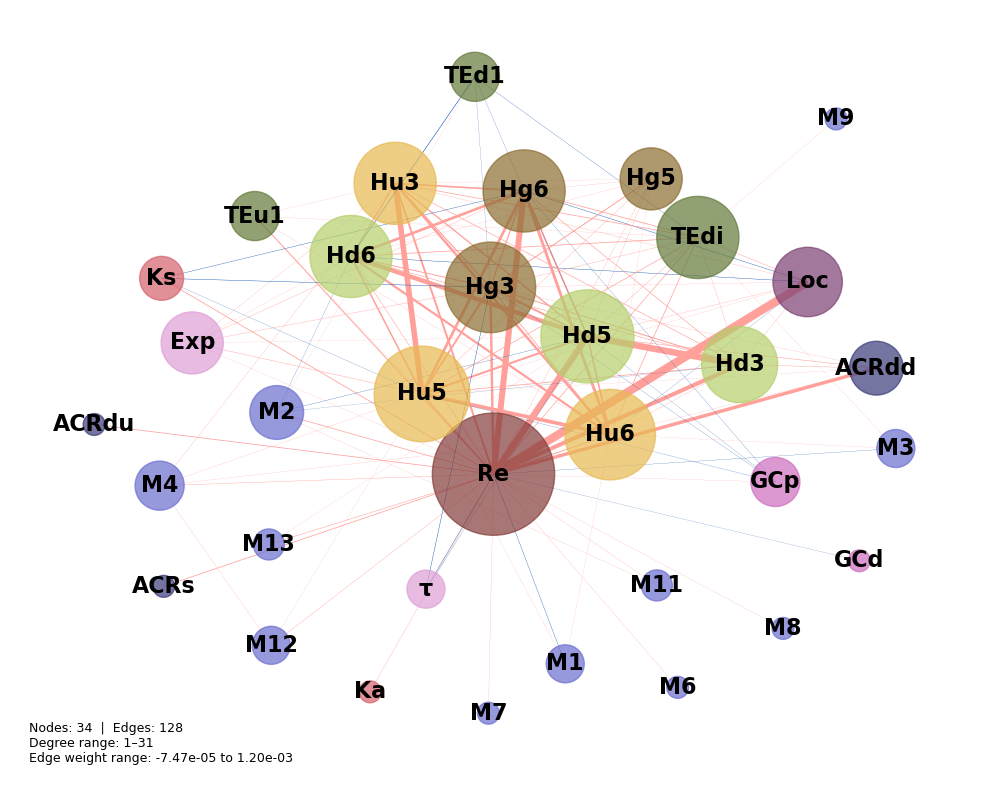


--- Group LF-MF2 (LF-MF2) — Permutation ---
  Running 1000 permutations... done.
  Null distribution size: 990,000 values
  Null abs mean: 0.000072
  Null abs std : 0.000356
  Total feature pairs : 990
  Significant edges   : 136
  Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_network/lf_mf2_all_permutation_all_edges.csv
  Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_network/lf_mf2_all_permutation_significant_edges.csv
  Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_network/lf_mf2_all_permutation_node_degrees.csv
  Nodes: 42  |  Edges: 136  |  Degree range: 1–40
  Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_network/lf_mf2_all_permutation_network.png


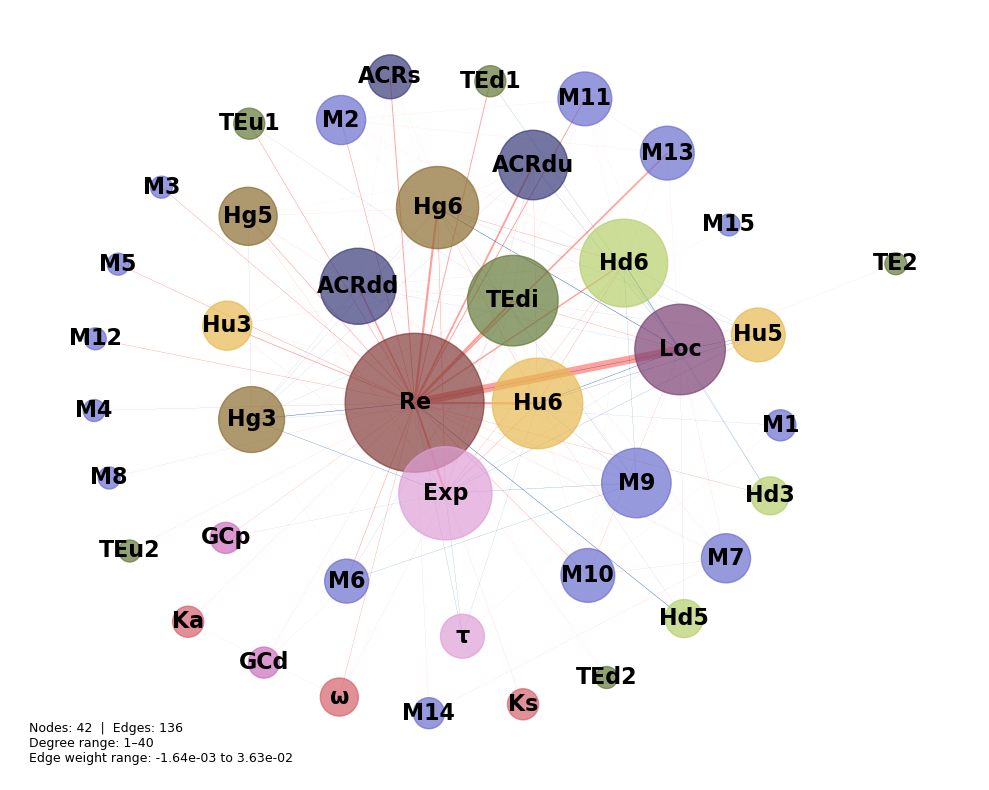


--- Group MF1-MF2 (MF1-MF2) — Permutation ---
  Running 1000 permutations... done.
  Null distribution size: 990,000 values
  Null abs mean: 0.000003
  Null abs std : 0.000013
  Total feature pairs : 990
  Significant edges   : 91
  Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_network/mf1_mf2_all_permutation_all_edges.csv
  Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_network/mf1_mf2_all_permutation_significant_edges.csv
  Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_network/mf1_mf2_all_permutation_node_degrees.csv
  Nodes: 39  |  Edges: 91  |  Degree range: 1–36
  Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_network/mf1_mf2_all_permutation_network.png


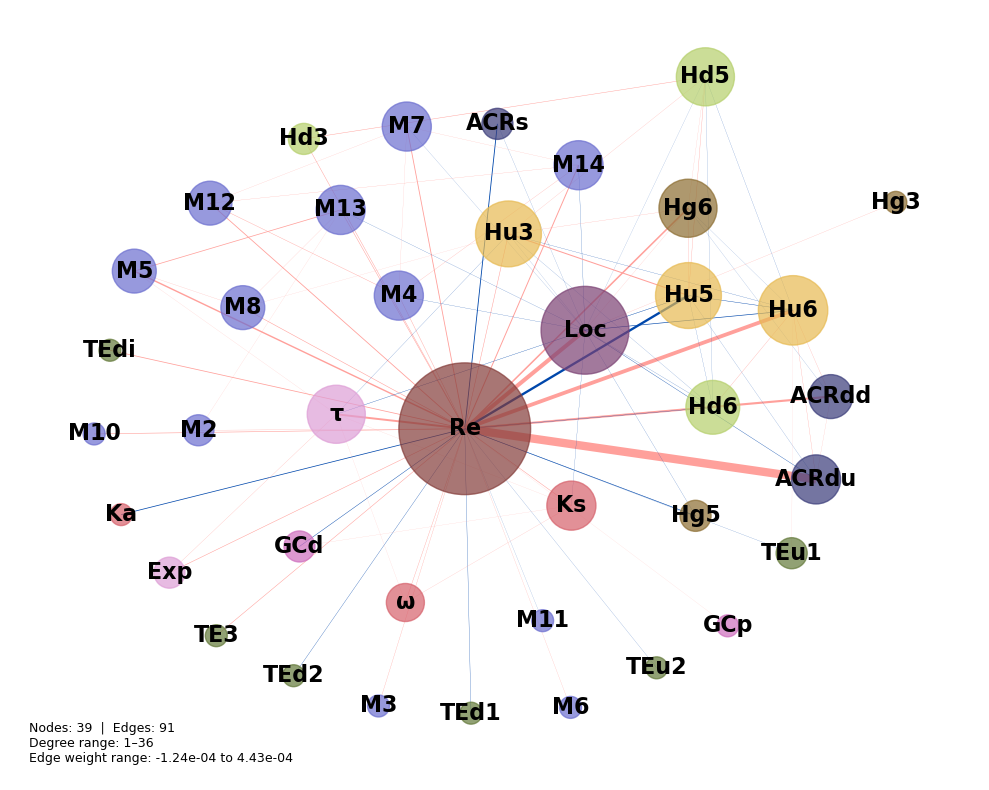

In [34]:
# ============================================================
# INDIVIDUAL NETWORK PLOTS — PERMUTATION METHOD
# ============================================================
# Constructs and plots one SHAP co-variation network per group
# (3 total) using permutation-based significance filtering.
# This is the primary significance method for the manuscript.
#
# METHODS NOTE — permutation approach:
# An empirical null distribution is constructed by permuting
# rows of the SHAP array (n_permutations=1000). Each permutation
# randomly reassigns each sample's full SHAP vector to a
# different sample, preserving the marginal distribution of
# each feature's SHAP values and within-sample feature
# correlations, while destroying systematic co-variation
# between features across samples. The co-variation matrix
# is recomputed for each permuted array and all upper-triangle
# scores are pooled into a single null distribution. The
# two-sided p-value for each observed feature pair score is
# the proportion of pooled null scores whose absolute value
# meets or exceeds the observed absolute score.
#
# Limitation: pooling all feature pairs into one null
# distribution assumes a shared null across pairs. Pairs
# involving features with higher SHAP variance may have
# inflated null scores. A per-pair null would be more
# precise but is computationally heavier and produces
# consistent results when SHAP variance is homogeneous
# across features.
#
# build_network_and_layout() and plot_single_network() are
# defined in Cell 9 and reused here without modification.
# ============================================================

# --- Generate individual permutation networks for all 5 groups ---

thickness = CUSTOM_THICKNESS.get(group, 8.0)

permutation_network_data = {}  # stores Gx and layout for Cell 12

for group in GROUPS:
    print(f"\n--- Group {group} ({GROUP_LABELS[group]}) "
          f"— Permutation ---")

    shap_array       = shap_data[group]["shap_all"]
    covariate_scores = covariation_data[group]["covariation_scores"]
    feat_labels      = feature_names[group]

    # Significance filtering
    sig_edges, all_edges = compute_permutation_significance(
        shap_array       = shap_array,
        covariate_scores = covariate_scores,
        feature_labels   = feat_labels,
        alpha            = ALPHA_PERMUTATION,
        n_permutations   = 1000,
        random_seed      = 42,
    )

    print(f"  Total feature pairs : {len(covariate_scores)}")
    print(f"  Significant edges   : {len(sig_edges)}")

    # Save edge tables
    all_edges_path = os.path.join(
        NETWORK_DIR,
        f"{PREFIXES[group]}_permutation_all_edges.csv"
    )
    sig_edges_path = os.path.join(
        NETWORK_DIR,
        f"{PREFIXES[group]}_permutation_significant_edges.csv"
    )

    all_edges.assign(
        source=all_edges['source'].map(feature_rename_dict).fillna(all_edges['source']),
        target=all_edges['target'].map(feature_rename_dict).fillna(all_edges['target'])
    ).to_csv(all_edges_path, index=False)

    sig_edges.assign(
        source=sig_edges['source'].map(feature_rename_dict).fillna(sig_edges['source']),
        target=sig_edges['target'].map(feature_rename_dict).fillna(sig_edges['target'])
    ).to_csv(sig_edges_path, index=False)
    
    print(f"  Saved: {all_edges_path}")
    print(f"  Saved: {sig_edges_path}")

    # Build graph and layout
    Gx, layout = build_network_and_layout(sig_edges)

    # Save degree table
    if Gx.number_of_nodes() > 0:
        degree_df = pd.DataFrame(
            Gx.degree, columns=['node', 'degree']
        ).sort_values(
            by='degree', ascending=False
        ).reset_index(drop=True)
        degree_path = os.path.join(
            NETWORK_DIR,
            f"{PREFIXES[group]}_permutation_node_degrees.csv"
        )
        degree_df.assign(
            node=degree_df['node'].map(feature_rename_dict).fillna(degree_df['node'])
        ).to_csv(degree_path, index=False)
        print(f"  Saved: {degree_path}")

    # Store for combined figure in Cell 12
    permutation_network_data[group] = {
        "Gx"       : Gx,
        "layout"   : layout,
        "sig_edges": sig_edges,
    }

    # Plot individual network
    plot_single_network(
        Gx                  = Gx,
        layout              = layout,
        title               = (None
            # f"SHAP Co-variation Network — {GROUP_LABELS[group]}\n"
            # f"(Permutation method, α={ALPHA_PERMUTATION}, n={1000})"
        ),
        save_path           = os.path.join(
            NETWORK_DIR,
            f"{PREFIXES[group]}_permutation_network.png"
        ),
        feature_rename_dict = feature_rename_dict,
        feature_to_group    = feature_to_group,
        group_to_color      = group_to_color,
        node_scaling_factor=250,
        max_edge_thickness=thickness,
    )

### Permutation Method: Combined Figure

Global max abs edge weight (Permutation method, n=1000,  α=0.05): 0.002286
Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_network/combined_permutation_network_groupI.png


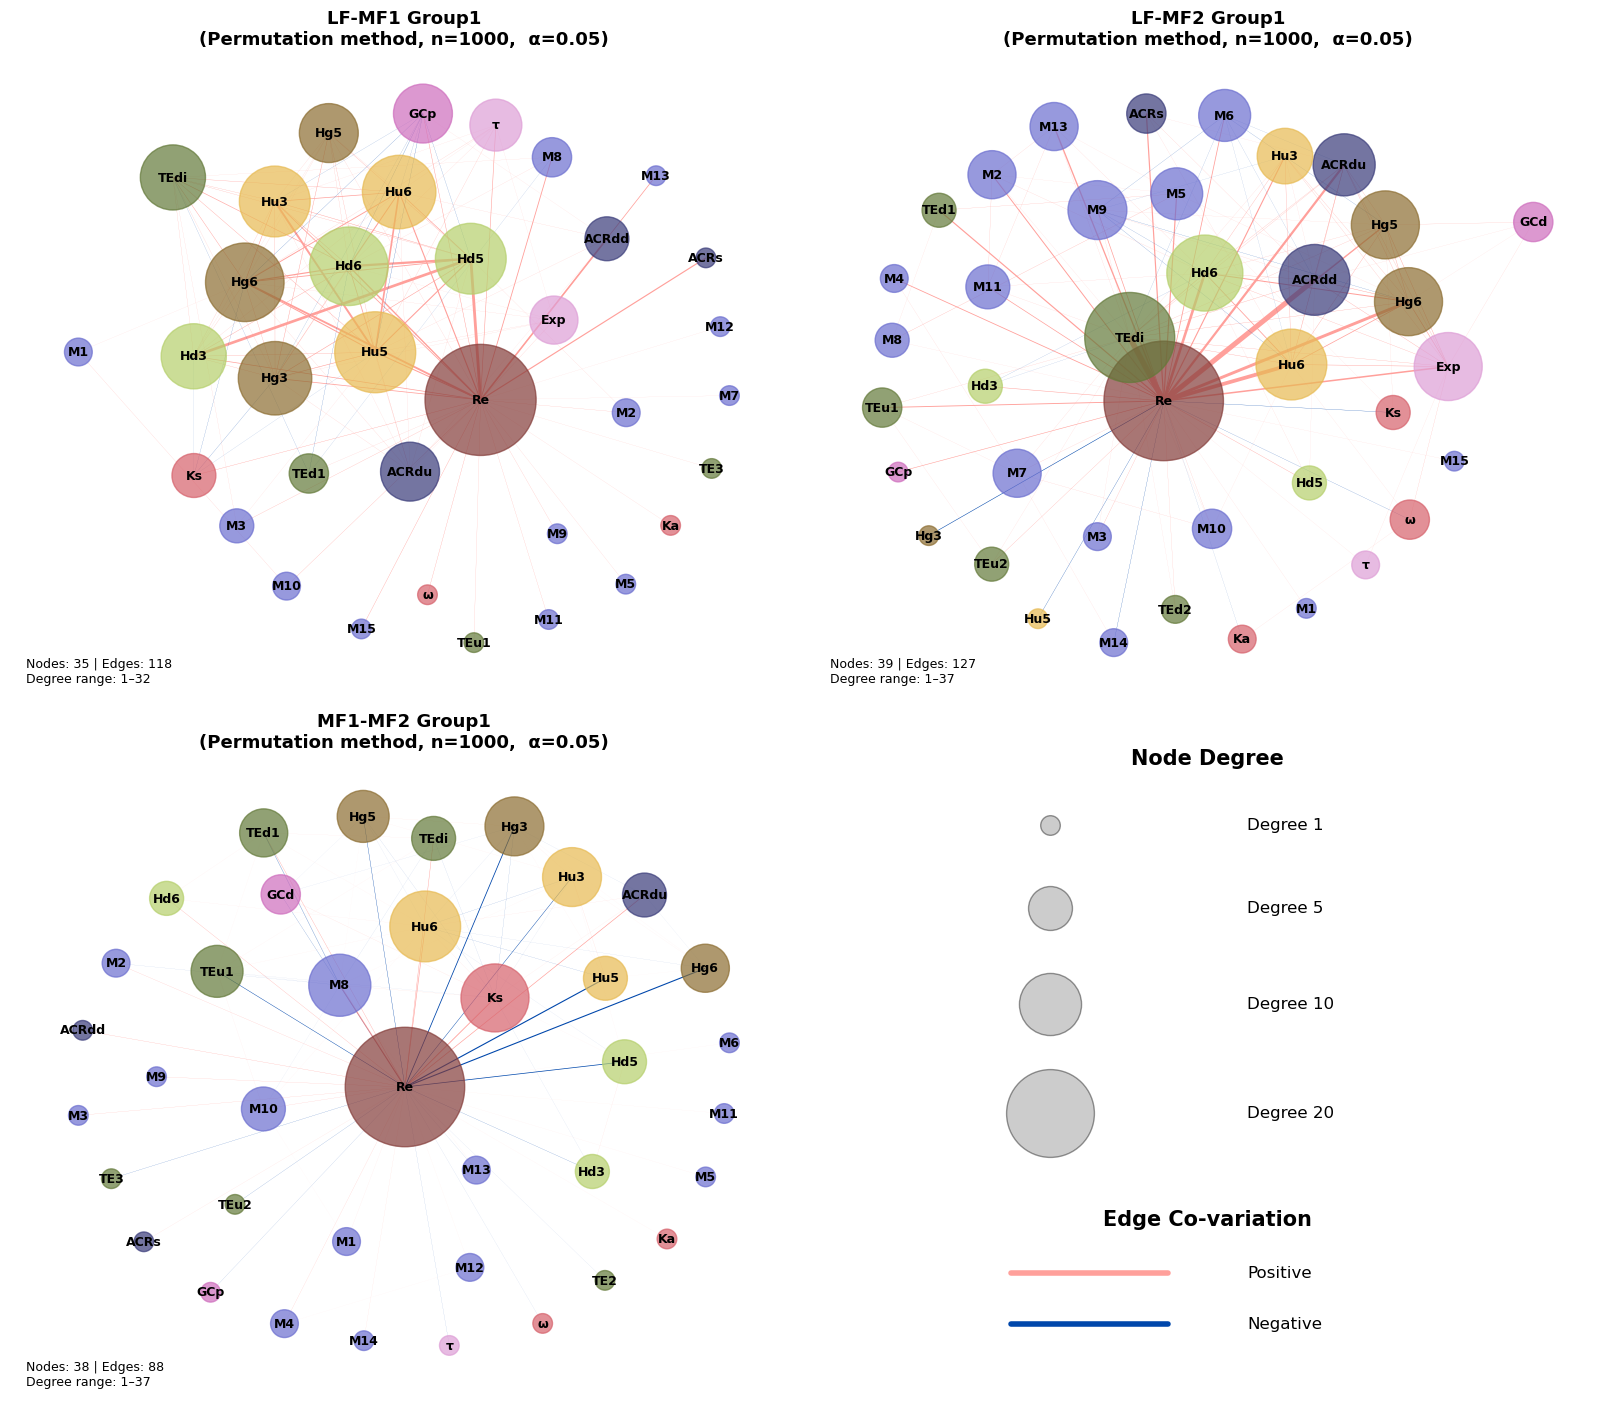

In [18]:
# ============================================================
# COMBINED 2×2 FIGURE — PERMUTATION METHOD
# ============================================================
# Produces the primary manuscript figure for the SHAP
# co-variation network analysis. Uses permutation-based
# significance filtering rather than the z-score
# approach.
# ============================================================

# --- Permutation combined figure (2×2) ---
plot_combined_networks_2x2(
    network_data      = permutation_network_data,
    group_labels      = GROUP_LABELS,
    feature_rename_dict = feature_rename_dict,
    feature_to_group  = feature_to_group,
    group_to_color    = group_to_color,
    save_path         = os.path.join(NETWORK_DIR, f"combined_permutation_network_{COMBINED_SUFFIX}.png"),
    method_label      = f"Permutation method, n=1000,  α={ALPHA_PERMUTATION}",
)

# SHAP Interaction Data

## Interaction Data Exploration

### Step 1: Violin Plots

Group LF-MF1_g1: 946 pairs | mean=-0.000001 | std=0.000086 | min=-0.000640 | max=0.001460
Group LF-MF2_g1: 946 pairs | mean=-0.000006 | std=0.000078 | min=-0.000923 | max=0.000758
Group MF1-MF2_g1: 946 pairs | mean=0.000001 | std=0.000024 | min=-0.000151 | max=0.000551
Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_network/interaction_distribution_violin_groupI.png


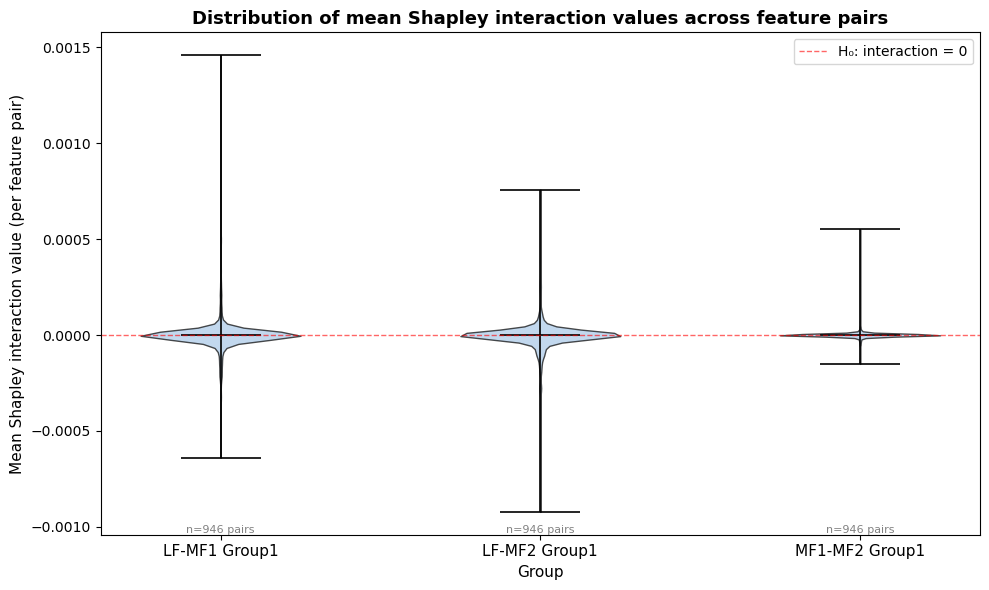

In [19]:
# ============================================================
# STEP 1: VIOLIN PLOTS — DISTRIBUTION OF MEAN INTERACTION
# VALUES PER FEATURE PAIR ACROSS GROUPS
# ============================================================
# For each group, computes the mean Shapley interaction value
# across samples for every upper-triangle feature pair.
# Plots distributions as violins on a shared axis to compare
# the spread and shape of interaction values across groups.
#
# Signed values are shown (not absolute) to reveal asymmetry.
# A symmetric distribution centered on zero would support the
# t-test assumption; asymmetry motivates non-parametric
# alternatives. The spread across groups informs whether a
# single effect size cutoff is appropriate for all groups.
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# --- Compute mean interaction value per pair for each group ---
# Result per group: 1D array of length n_pairs (upper triangle only)
mean_interaction_per_pair = {}

for group in GROUPS:
    interact = shap_data[group]["shap_interaction_all"]  
    # shape: (n_samples, n_features, n_features)
    n_features = interact.shape[1]

    # Mean across samples for each pair, then extract upper triangle
    mean_matrix = interact.mean(axis=0)  
    # shape: (n_features, n_features)

    upper_mask = np.triu(np.ones((n_features, n_features), dtype=bool), k=1)
    pair_means = mean_matrix[upper_mask]  
    # shape: (n_pairs,) — signed mean interaction per pair

    mean_interaction_per_pair[group] = pair_means

    print(f"Group {group}: {len(pair_means)} pairs | "
          f"mean={pair_means.mean():.6f} | "
          f"std={pair_means.std():.6f} | "
          f"min={pair_means.min():.6f} | "
          f"max={pair_means.max():.6f}")

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 6))

violin_data  = [mean_interaction_per_pair[g] for g in GROUPS]
violin_parts = ax.violinplot(
    violin_data,
    positions   = range(len(GROUPS)),
    showmedians = True,
    showextrema = True,
)

# Style violins
for pc in violin_parts["bodies"]:
    pc.set_facecolor("#a8c8e8")
    pc.set_edgecolor("black")
    pc.set_alpha(0.7)
for part in ["cmedians", "cmins", "cmaxes", "cbars"]:
    violin_parts[part].set_color("black")
    violin_parts[part].set_linewidth(1.2)

# Zero reference line — H0: interaction = 0
ax.axhline(0, color="red", linestyle="--", linewidth=1.0, alpha=0.6, label="H₀: interaction = 0")

ax.set_xticks(range(len(GROUPS)))
ax.set_xticklabels([GROUP_LABELS[g] for g in GROUPS], fontsize=11)
ax.set_ylabel("Mean Shapley interaction value (per feature pair)", fontsize=11)
ax.set_xlabel("Group", fontsize=11)
ax.set_title(
    "Distribution of mean Shapley interaction values across feature pairs",
    fontsize=13, fontweight="bold"
)
ax.legend(fontsize=10)

# Annotate n pairs per group
for i, group in enumerate(GROUPS):
    n = len(mean_interaction_per_pair[group])
    ax.annotate(
        f"n={n:,} pairs",
        xy=(i, ax.get_ylim()[0]),
        xycoords="data",
        fontsize=8,
        ha="center", va="bottom",
        color="gray"
    )

plt.tight_layout()
save_path = os.path.join(NETWORK_DIR, f"interaction_distribution_violin_{COMBINED_SUFFIX}.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Saved: {save_path}")
plt.show()
plt.close()

### Step 2: Retention Curves

Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_network/interaction_retention_curves_groupI.png


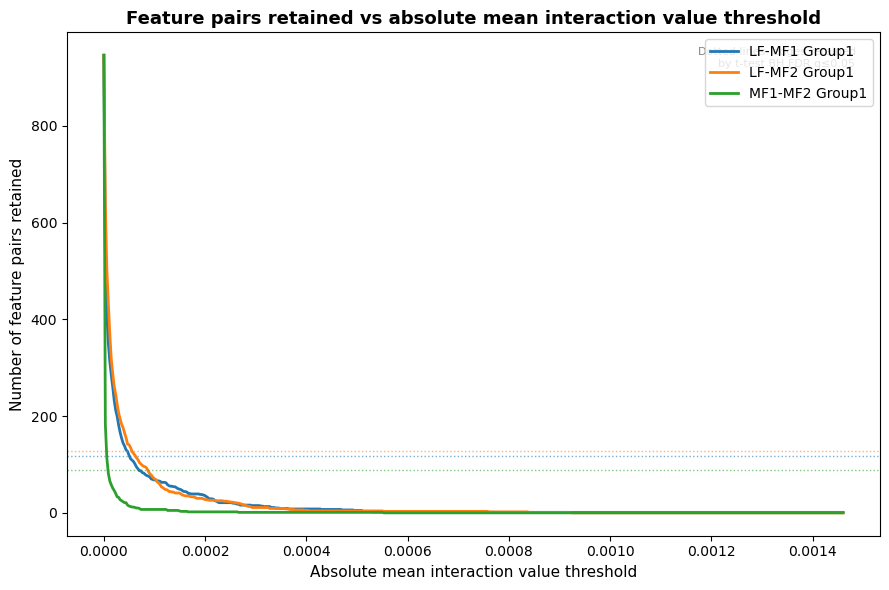

In [20]:
# ============================================================
# STEP 2: RETENTION CURVES — EDGES RETAINED VS ABSOLUTE
# WEIGHT THRESHOLD
# ============================================================
# For each group, sweeps a range of absolute mean interaction
# value cutoffs and counts how many feature pairs survive.
# Helps identify a natural elbow — a threshold where the
# curve flattens, suggesting diminishing returns from lowering
# the cutoff further.
#
# All three pairwise groups are plotted on a shared axis.
# If the value ranges differ substantially after running,
# consider splitting into separate panels.
#
# Horizontal dashed lines show the number of significant edges
# retained by the t-test + BH FDR approach (q<=0.05) for
# reference. These values must be filled in manually after
# the interaction network loop has been run once.
#
# Uses mean_interaction_per_pair computed in Step 1.
# ============================================================

# --- Compute retention curves ---
# For each group: array of absolute mean interaction values
abs_means = {
    group: np.abs(mean_interaction_per_pair[group])
    for group in GROUPS
}

# Single shared threshold range across all three groups.
# Upper bound is the maximum observed absolute interaction
# value across all groups so all curves reach zero retention.
n_points   = 500
global_max = max(abs_means[group].max() for group in GROUPS)
thresholds = np.linspace(0, global_max, n_points)

def retention_counts(abs_vals, thresholds):
    """Count pairs surviving each threshold."""
    return np.array([(abs_vals >= t).sum() for t in thresholds])

retention = {
    group: retention_counts(abs_means[group], thresholds)
    for group in GROUPS
}

# --- Colors for the three pairwise groups ---
group_colors = GROUP_COLORS

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 6))

for group in GROUPS:
    ax.plot(
        thresholds,
        retention[group],
        label     = GROUP_LABELS[group],
        color     = group_colors[group],
        linewidth = 2.0,
    )
    # Horizontal reference: significant edge count from t-test
    n_sig = SIG_EDGE_COUNTS[group]
    if n_sig > 0:
        ax.axhline(
            n_sig,
            color     = group_colors[group],
            linestyle = ":",
            linewidth = 1.0,
            alpha     = 0.6,
        )

ax.set_xlabel("Absolute mean interaction value threshold", fontsize=11)
ax.set_ylabel("Number of feature pairs retained", fontsize=11)
ax.set_title(
    "Feature pairs retained vs absolute mean interaction value threshold",
    fontsize=13, fontweight="bold"
)
ax.legend(fontsize=10)
ax.annotate(
    "Dotted lines: edges retained\nby t-test BH FDR q≤0.05",
    xy=(0.97, 0.97), xycoords="axes fraction",
    fontsize=8, ha="right", va="top", color="gray",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7, ec="none")
)

plt.tight_layout()
save_path = os.path.join(NETWORK_DIR, f"interaction_retention_curves_{COMBINED_SUFFIX}.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Saved: {save_path}")
plt.show()
plt.close()

### Step 3: Interaction Magnitude vs Main Effect Magnitude

Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_network/interaction_vs_maineffect_groupI.png


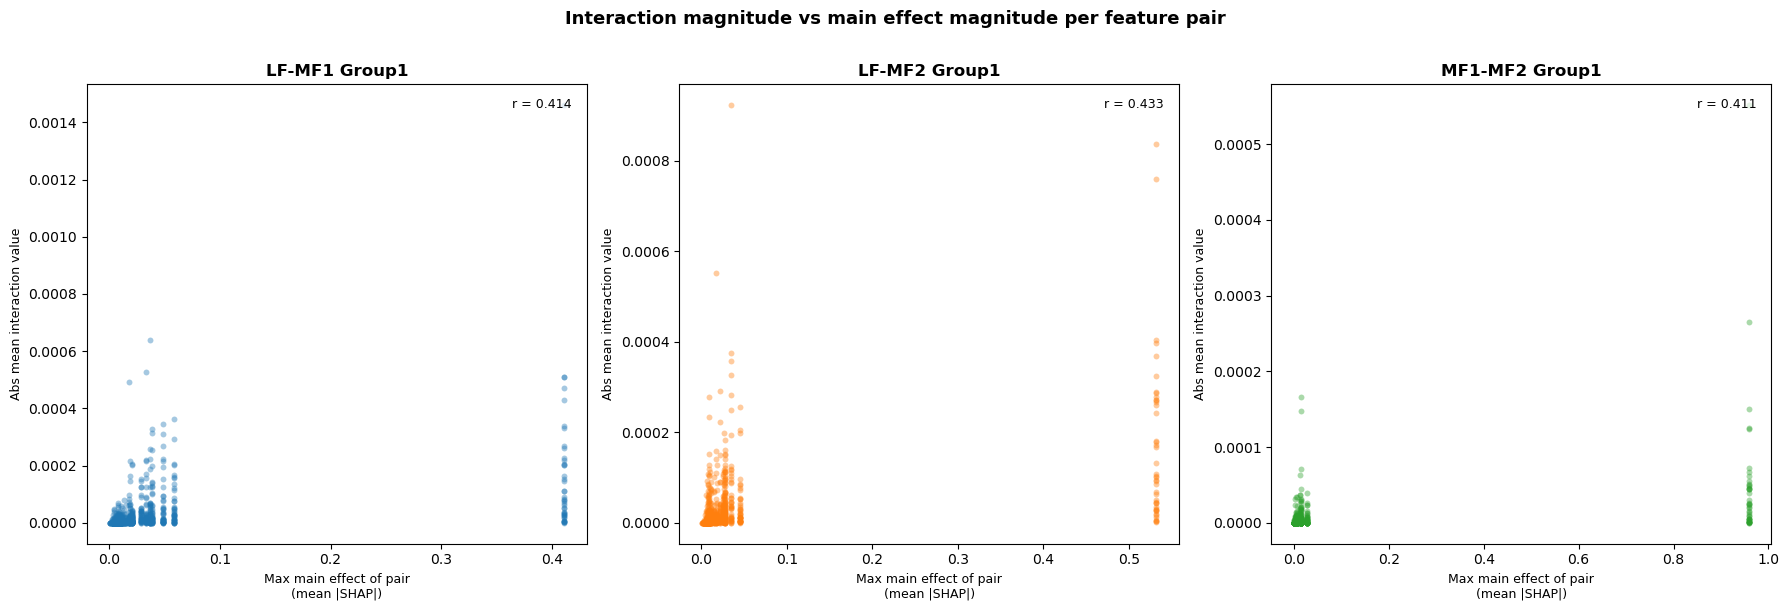

In [21]:
# ============================================================
# STEP 3: INTERACTION MAGNITUDE VS MAIN EFFECT MAGNITUDE
# ============================================================
# For each group, plots the absolute mean interaction value
# per feature pair against the main effect of that pair,
# defined as max(mean_abs_shap[j], mean_abs_shap[k]).
#
# Main effect: mean(abs(shap_all[:, j])) for feature j —
# how much feature j contributes on average to predictions
# regardless of direction. The maximum of the two features
# in a pair is used because the stronger individual
# contributor dominates the pair's main effect context.
#
# Motivation: if large interactions only occur between
# features that also have large main effects, the interaction
# signal may be secondary to main effect structure. If large
# interactions occur between low-main-effect features, that
# is more surprising and biologically interesting.
#
# All three pairwise groups share a single row. Axes are NOT
# shared because the groups may have different value ranges —
# the goal is to see structure within each group, not to
# compare absolute magnitudes across groups (the retention
# curves already show that).
#
# Uses mean_interaction_per_pair from Step 1.
# ============================================================

group_colors_scatter = GROUP_COLORS

fig, axes = plt.subplots(
    1, 3,
    figsize = (18, 6),
)

for col, group in enumerate(GROUPS):
    ax = axes[col]

    # --- Main effects: mean abs SHAP per feature ---
    shap_all_group = shap_data[group]["shap_all"]
    mean_abs_shap  = np.abs(shap_all_group).mean(axis=0)
    # shape: (n_features,)

    # --- Build pair-level arrays from interaction matrix ---
    interact     = shap_data[group]["shap_interaction_all"]
    mean_matrix  = interact.mean(axis=0)
    n_features   = mean_matrix.shape[0]

    pair_main  = []
    pair_inter = []

    for j in range(n_features):
        for k in range(j + 1, n_features):
            pair_main.append(max(mean_abs_shap[j], mean_abs_shap[k]))
            pair_inter.append(abs(mean_matrix[j, k]))

    pair_main  = np.array(pair_main)
    pair_inter = np.array(pair_inter)

    ax.scatter(
        pair_main,
        pair_inter,
        alpha      = 0.4,
        s          = 18,
        color      = group_colors_scatter[group],
        linewidths = 0,
    )
    ax.set_title(GROUP_LABELS[group], fontsize=12, fontweight="bold")
    ax.set_xlabel("Max main effect of pair\n(mean |SHAP|)", fontsize=9)
    ax.set_ylabel("Abs mean interaction value", fontsize=9)

    # Pearson correlation annotation
    r = np.corrcoef(pair_main, pair_inter)[0, 1]
    ax.annotate(
        f"r = {r:.3f}",
        xy=(0.97, 0.97), xycoords="axes fraction",
        fontsize=9, ha="right", va="top",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7, ec="none")
    )

fig.suptitle(
    "Interaction magnitude vs main effect magnitude per feature pair",
    fontsize=13, fontweight="bold", y=1.01
)

plt.tight_layout()
save_path = os.path.join(NETWORK_DIR, f"interaction_vs_maineffect_{COMBINED_SUFFIX}.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Saved: {save_path}")
plt.show()
plt.close()

### Step 3.1: Identify Rightmost Outliers per Group

In [22]:
# ============================================================
# IDENTIFY RIGHTMOST OUTLIER FEATURES PER GROUP
# ============================================================
# For each group, finds which feature has the highest mean
# absolute SHAP value (main effect), and reports the top N
# pairs by max main effect to confirm which feature drives
# the rightmost cluster in the scatter plots.
# ============================================================

print("Top 5 features by mean |SHAP| (main effect) per group:\n")

top_feature_per_group = {}

for group in GROUPS:
    shap_array   = shap_data[group]["shap_all"]
    mean_abs     = np.abs(shap_array).mean(axis=0)
    feat_names   = feature_names[group]

    # Rank features by mean abs SHAP
    ranked_idx   = np.argsort(mean_abs)[::-1]

    print(f"--- Group {group} ({GROUP_LABELS[group]}) ---")
    for rank, idx in enumerate(ranked_idx[:5]):
        print(f"  {rank+1}. {feat_names[idx]:<25} "
              f"mean |SHAP| = {mean_abs[idx]:.6f}")

    top_feature_per_group[group] = feat_names[ranked_idx[0]]
    print()

print("\nTop 5 pairs by max main effect per group:\n")

for group in GROUPS:
    shap_array   = shap_data[group]["shap_all"]
    mean_abs     = np.abs(shap_array).mean(axis=0)
    feat_names   = feature_names[group]
    interact     = shap_data[group]["shap_interaction_all"]
    mean_matrix  = interact.mean(axis=0)
    n_features   = len(feat_names)

    pair_records = []
    for j in range(n_features):
        for k in range(j + 1, n_features):
            pair_records.append({
                "feature_j"   : feat_names[j],
                "feature_k"   : feat_names[k],
                "max_main"    : max(mean_abs[j], mean_abs[k]),
                "abs_interact": abs(mean_matrix[j, k]),
            })

    pair_df = pd.DataFrame(pair_records).sort_values(
        "max_main", ascending=False
    ).reset_index(drop=True)

    print(f"--- Group {group} ({GROUP_LABELS[group]}) ---")
    print(pair_df[["feature_j", "feature_k",
                   "max_main", "abs_interact"]].head(5).to_string(index=False))
    print()
    

Top 5 features by mean |SHAP| (main effect) per group:

--- Group LF-MF1_g1 (LF-MF1 Group1) ---
  1. rec_rate                  mean |SHAP| = 0.411181
  2. H3K27ac_down              mean |SHAP| = 0.058070
  3. H3K27me3_down             mean |SHAP| = 0.048353
  4. H3K27me3_genebody         mean |SHAP| = 0.038630
  5. H3K27ac_up                mean |SHAP| = 0.036540

--- Group LF-MF2_g1 (LF-MF2 Group1) ---
  1. rec_rate                  mean |SHAP| = 0.532068
  2. downstream_distance       mean |SHAP| = 0.044801
  3. H3K27me3_genebody         mean |SHAP| = 0.034481
  4. H3K27me3_down             mean |SHAP| = 0.028040
  5. H3K27me3_up               mean |SHAP| = 0.027919

--- Group MF1-MF2_g1 (MF1-MF2 Group1) ---
  1. rec_rate                  mean |SHAP| = 0.958085
  2. Ks                        mean |SHAP| = 0.027093
  3. TEdenseAvgDown            mean |SHAP| = 0.015915
  4. CG_down_ave               mean |SHAP| = 0.015397
  5. H3K27me3_up               mean |SHAP| = 0.014133


Top 5 pa

### Step 4: K-Sweep Median + k × MAD Threshold with Zeros

Group-specific threshold components:

Group LF-MF1_g1:
  Median abs interaction : 0.00000427
  MAD                    : 0.00000403
  Ratio median/MAD       : 1.06

Group LF-MF2_g1:
  Median abs interaction : 0.00000716
  MAD                    : 0.00000633
  Ratio median/MAD       : 1.13

Group MF1-MF2_g1:
  Median abs interaction : 0.00000000
  MAD                    : 0.00000000
  Ratio median/MAD       : undefined (MAD=0)

Edges retained per group across k values:

      LF-MF1_g1  LF-MF2_g1  MF1-MF2_g1
k                                     
1.0         358        329         445
1.5         328        298         445
2.0         305        267         445
2.5         288        247         445
3.0         270        226         445
3.5         252        206         445
4.0         232        193         445
4.5         218        183         445
5.0         207        171         445
5.5         198        161         445
6.0         181        149         445
6.5         176     

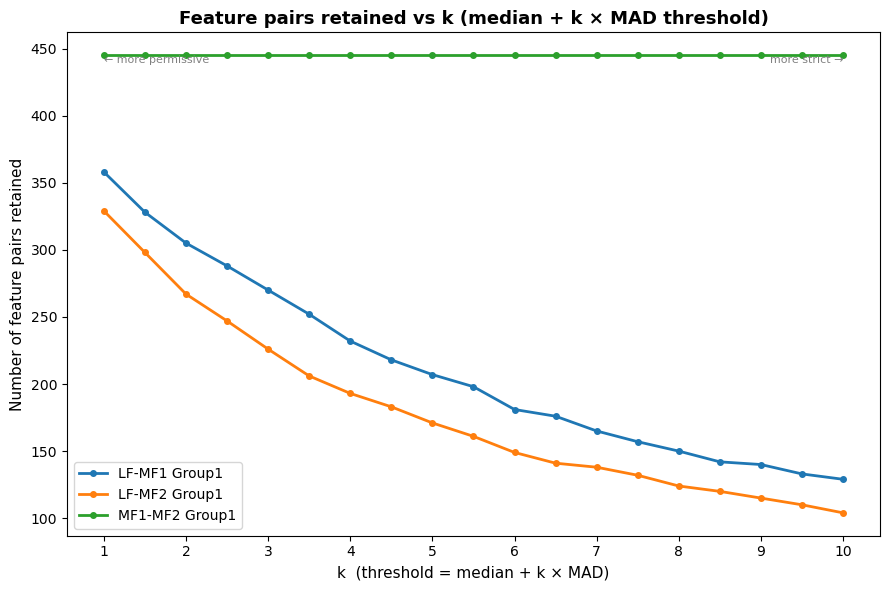

Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_network/interaction_ksweep_scatter_overlay_groupI.png


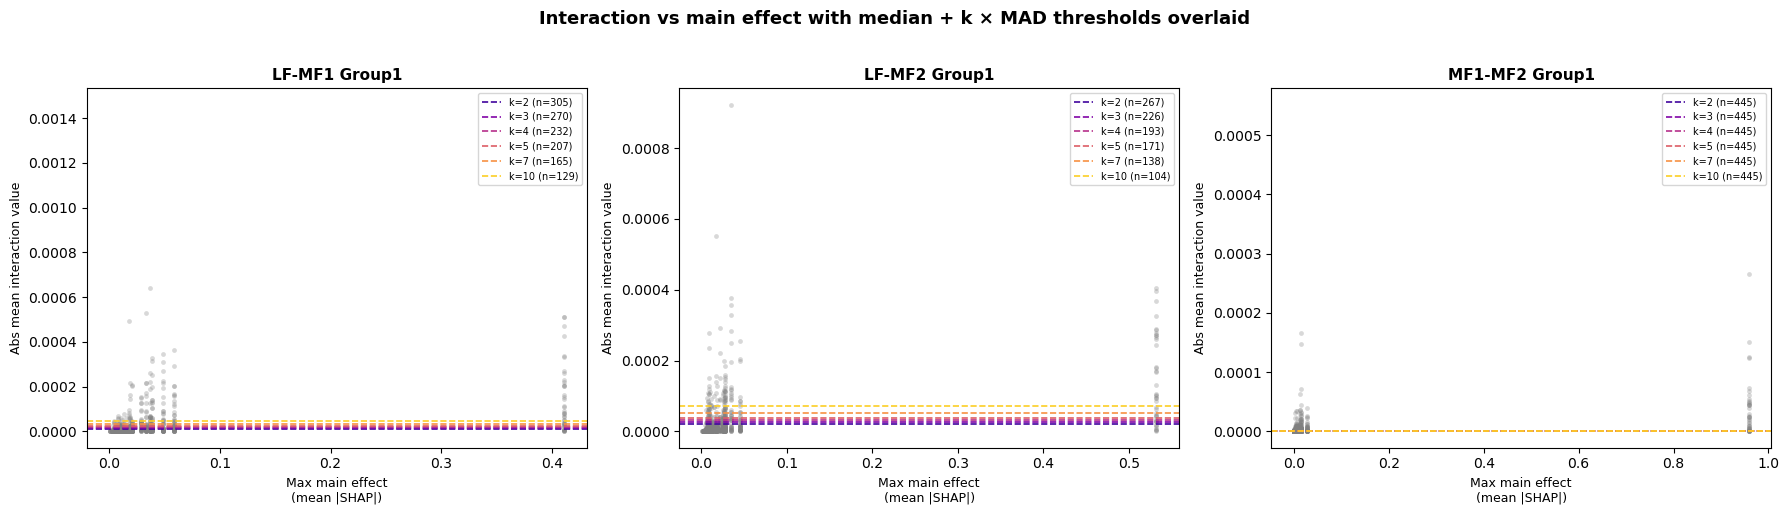

In [23]:
# ============================================================
# K-SWEEP: MEDIAN + k × MAD THRESHOLD
# ============================================================
# For each group, computes a robust effect-size threshold
# using the median and MAD (median absolute deviation) of
# all absolute mean interaction values across feature pairs.
#
# The threshold for a given k is:
#   threshold = median(abs_mean_interactions)
#               + k * MAD(abs_mean_interactions)
#
# Any pair whose absolute mean interaction value exceeds this
# threshold is retained as a meaningful interaction for that
# group. Pairs below it are considered indistinguishable from
# the group's own noise floor.
#
# WHY MEDIAN AND MAD INSTEAD OF MEAN AND STD:
# From the violin plots, the distribution of interaction values
# is typically heavily skewed with most pairs near zero.
# The mean and standard deviation are sensitive to these
# extreme values. The median and MAD are resistant to outliers
# — they describe the center and spread of the bulk of the
# distribution, not the extremes.
#
# WHY THIS IS GROUP-SPECIFIC:
# The absolute scale of interaction values may differ across
# pairwise comparisons (as shown in the violin plots and
# retention curves). Using each group's own median and MAD
# means "meaningful" is defined relative to that group's
# noise floor, not a global cutoff. If a group's interactions
# are genuinely all near zero relative to its own spread,
# no edges will survive — and that is a real biological result.
#
# OUTPUTS:
# 1. A table of edges retained per group across k values
# 2. A line plot of retention vs k per group
# 3. The step 3 scatter plot with thresholds overlaid
# ============================================================

from scipy.stats import median_abs_deviation

# --- Compute group-specific median and MAD ---
# These are fixed per group — only k varies in the sweep
print("Group-specific threshold components:\n")

group_medians = {}
group_mads    = {}

for group in GROUPS:
    abs_vals = np.abs(mean_interaction_per_pair[group])

    med = np.median(abs_vals)
    mad = median_abs_deviation(abs_vals, scale=1)

    group_medians[group] = med
    group_mads[group]    = mad

    print(f"Group {group}:")
    print(f"  Median abs interaction : {med:.8f}")
    print(f"  MAD                    : {mad:.8f}")
    print(f"  Ratio median/MAD       : "
          f"{med/mad:.2f}" if mad > 0 else "  Ratio median/MAD       : undefined (MAD=0)")
    print()

# --- Define k sweep range ---
# k=1 to k=10 in steps of 0.5
# Lower k = more permissive (more edges retained)
# Higher k = more strict (fewer edges retained)
k_values = np.arange(1, 10.5, 0.5)

# --- Compute retention count for each group at each k ---
print("Edges retained per group across k values:\n")

retention_rows = []
for k in k_values:
    row = {"k": k}
    for group in GROUPS:
        abs_vals   = np.abs(mean_interaction_per_pair[group])
        threshold  = group_medians[group] + k * group_mads[group]
        n_retained = (abs_vals > threshold).sum()
        row[group] = n_retained
    retention_rows.append(row)

retention_df = pd.DataFrame(retention_rows).set_index("k")
print(retention_df.to_string())
print()

retention_table_path = os.path.join(
    NETWORK_DIR, f"interaction_ksweep_retention_table_{COMBINED_SUFFIX}.csv"
)
retention_df.to_csv(retention_table_path)
print(f"Saved retention table: {retention_table_path}\n")

# ============================================================
# PLOT 1: RETENTION CURVES ACROSS K VALUES
# ============================================================
# One line per group showing how many edges survive as k
# increases. All three pairwise groups on a shared panel.
# The x-axis is k so all groups are directly comparable.
# ============================================================

group_colors_sweep   = GROUP_COLORS

fig, ax = plt.subplots(figsize=(9, 6))

for group in GROUPS:
    ax.plot(
        k_values,
        retention_df[group].values,
        label     = GROUP_LABELS[group],
        color     = group_colors_sweep[group],
        linewidth = 2.0,
        marker    = "o",
        markersize= 4,
    )

ax.set_xlabel("k  (threshold = median + k × MAD)", fontsize=11)
ax.set_ylabel("Number of feature pairs retained", fontsize=11)
ax.set_title(
    "Feature pairs retained vs k (median + k × MAD threshold)",
    fontsize=13, fontweight="bold"
)
ax.legend(fontsize=10)
ax.set_xticks(k_values[::2])
ax.annotate(
    "← more permissive",
    xy=(k_values[0], ax.get_ylim()[1] * 0.95),
    fontsize=8, color="gray", ha="left"
)
ax.annotate(
    "more strict →",
    xy=(k_values[-1], ax.get_ylim()[1] * 0.95),
    fontsize=8, color="gray", ha="right"
)

plt.tight_layout()
save_path = os.path.join(NETWORK_DIR, f"interaction_ksweep_retention_curves_{COMBINED_SUFFIX}.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Saved: {save_path}")
plt.show()
plt.close()

# ============================================================
# PLOT 2: STEP 3 SCATTER WITH K THRESHOLDS OVERLAID
# ============================================================
# Recreates the interaction magnitude vs main effect scatter
# from Step 3, but adds horizontal lines showing where the
# threshold falls for selected k values.
# This lets you see visually which pairs survive at each k
# and whether the surviving pairs make biological sense.
# ============================================================

k_to_show = [2, 3, 4, 5, 7, 10]
k_colors  = plt.cm.plasma(np.linspace(0.1, 0.9, len(k_to_show)))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax_idx, group in enumerate(GROUPS):
    ax = axes[ax_idx]

    shap_array    = shap_data[group]["shap_all"]
    mean_abs_shap = np.abs(shap_array).mean(axis=0)
    interact      = shap_data[group]["shap_interaction_all"]
    mean_matrix   = interact.mean(axis=0)
    n_features    = len(feature_names[group])

    pair_main  = []
    pair_inter = []
    for j in range(n_features):
        for k_idx in range(j + 1, n_features):
            pair_main.append(max(mean_abs_shap[j], mean_abs_shap[k_idx]))
            pair_inter.append(abs(mean_matrix[j, k_idx]))

    pair_main  = np.array(pair_main)
    pair_inter = np.array(pair_inter)

    ax.scatter(
        pair_main, pair_inter,
        alpha=0.3, s=12, color="gray",
        linewidths=0, label="_nolegend_", zorder=1,
    )

    for k_line, color in zip(k_to_show, k_colors):
        threshold = group_medians[group] + k_line * group_mads[group]
        n_above   = (pair_inter > threshold).sum()
        ax.axhline(
            threshold,
            color=color, linewidth=1.2, linestyle="--",
            label=f"k={k_line} (n={n_above})", zorder=2,
        )

    ax.set_title(GROUP_LABELS[group], fontsize=11, fontweight="bold")
    ax.set_xlabel("Max main effect\n(mean |SHAP|)", fontsize=9)
    ax.set_ylabel("Abs mean interaction value", fontsize=9)
    ax.legend(fontsize=7, loc="upper right")

fig.suptitle(
    "Interaction vs main effect with median + k × MAD thresholds overlaid",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
save_path = os.path.join(NETWORK_DIR, f"interaction_ksweep_scatter_overlay_{COMBINED_SUFFIX}.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Saved: {save_path}")
plt.show()
plt.close()

### Step 4.1: K-Sweep Median + k × MAD Threshold Non-Zeros

Non-zero pair counts and threshold components per group:

Group LF-MF1_g1 (LF-MF1 Group1):
  Total pairs     : 946
  Non-zero pairs  : 926 (97.9% of all pairs)
  Median (nonzero): 0.00000442
  MAD   (nonzero) : 0.00000408
  Ratio med/MAD   : 1.08
  Example thresholds:
    k= 3: threshold=0.00001667, pairs retained=267
    k= 5: threshold=0.00002484, pairs retained=206
    k= 7: threshold=0.00003301, pairs retained=164
    k=10: threshold=0.00004526, pairs retained=128
    k=12: threshold=0.00005343, pairs retained=111
    k=15: threshold=0.00006569, pairs retained=93

Group LF-MF2_g1 (LF-MF2 Group1):
  Total pairs     : 946
  Non-zero pairs  : 946 (100.0% of all pairs)
  Median (nonzero): 0.00000716
  MAD   (nonzero) : 0.00000633
  Ratio med/MAD   : 1.13
  Example thresholds:
    k= 3: threshold=0.00002614, pairs retained=226
    k= 5: threshold=0.00003880, pairs retained=171
    k= 7: threshold=0.00005146, pairs retained=138
    k=10: threshold=0.00007045, pairs retained=104
    k=12:

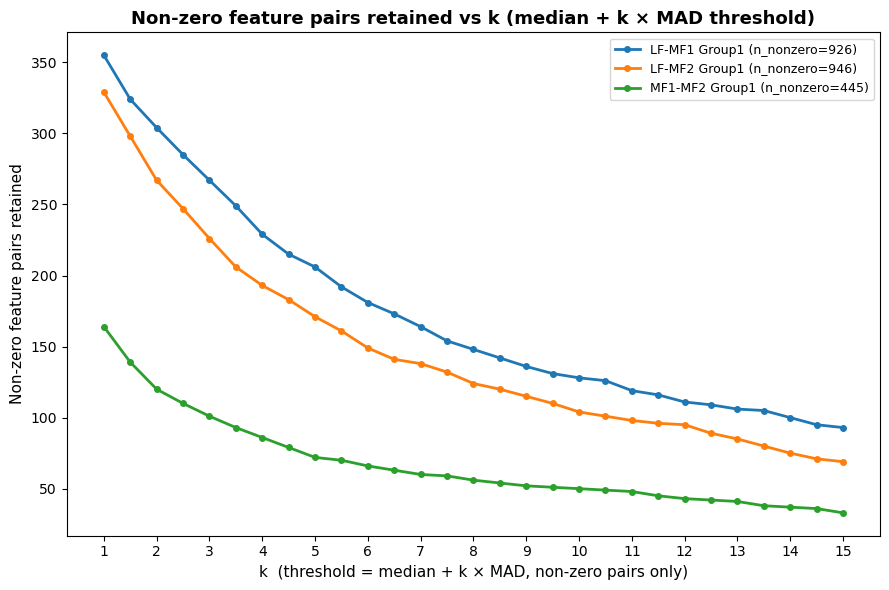

Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_network/interaction_ksweep_scatter_overlay_nonzero_groupI.png


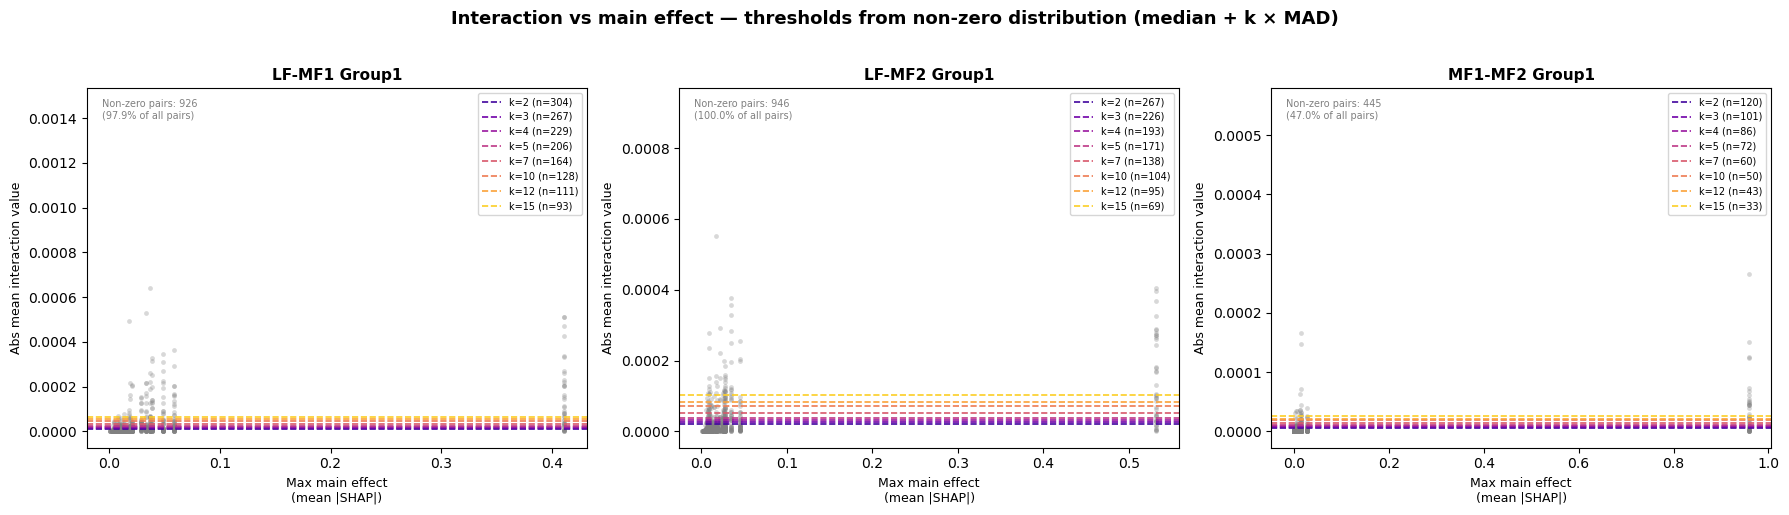

In [24]:
# ============================================================
# K-SWEEP (REVISED): MEDIAN + k × MAD THRESHOLD
# COMPUTED FROM NON-ZERO PAIRS ONLY
# ============================================================
#
# WHY WE RESTRICT TO NON-ZERO PAIRS:
# When a large fraction of pairs have exactly zero interaction,
# the median of all pairs is zero and the MAD is also zero.
# This makes the threshold:
#   median + k × 0 = 0  for any k
# meaning every non-zero pair passes regardless of k — the
# sweep has no discriminating effect.
#
# Restricting to non-zero pairs changes the question from:
#   "Is this pair unusual among ALL pairs?"
# to:
#   "Is this pair unusual among pairs that actually show
#    a detectable interaction?"
#
# The zero pairs are TRUE zeros — those feature combinations
# have no interaction effect in the model whatsoever. They
# should not define the noise floor. The noise floor should
# come from the distribution of pairs that DO have some
# interaction, however small.
#
# Inspect the output below to see what fraction of pairs
# are non-zero per group — if a group has most pairs at
# zero, the non-zero sweep is essential; if most are
# non-zero, the two sweeps will give similar results.
#
# The threshold for a given k and group is:
#   threshold = median(nonzero_abs_interactions)
#               + k × MAD(nonzero_abs_interactions)
#
# Any pair with abs mean interaction > threshold is retained.
# Pairs that are exactly zero are always excluded.
# ============================================================

from scipy.stats import median_abs_deviation

# --- Step 1: Compute non-zero absolute mean interactions ---
print("Non-zero pair counts and threshold components per group:\n")

abs_means_nonzero = {}
n_total           = {}
n_nonzero         = {}
group_medians_nz  = {}
group_mads_nz     = {}

for group in GROUPS:
    abs_vals = np.abs(mean_interaction_per_pair[group])

    nonzero_mask = abs_vals > 0.0
    nonzero_vals = abs_vals[nonzero_mask]

    abs_means_nonzero[group] = nonzero_vals
    n_total[group]           = len(abs_vals)
    n_nonzero[group]         = nonzero_mask.sum()

    med = np.median(nonzero_vals)
    mad = median_abs_deviation(nonzero_vals, scale=1)

    group_medians_nz[group] = med
    group_mads_nz[group]    = mad

    pct_nonzero = 100 * n_nonzero[group] / n_total[group]
    print(f"Group {group} ({GROUP_LABELS[group]}):")
    print(f"  Total pairs     : {n_total[group]:,}")
    print(f"  Non-zero pairs  : {n_nonzero[group]:,} "
          f"({pct_nonzero:.1f}% of all pairs)")
    print(f"  Median (nonzero): {med:.8f}")
    print(f"  MAD   (nonzero) : {mad:.8f}")
    if mad > 0:
        print(f"  Ratio med/MAD   : {med/mad:.2f}")
    else:
        print(f"  WARNING: MAD is zero even among non-zero pairs. "
              f"All non-zero pairs have identical values.")
    print(f"  Example thresholds:")
    for k_ex in [3, 5, 7, 10, 12, 15]:
        t = med + k_ex * mad
        n = (nonzero_vals > t).sum()
        print(f"    k={k_ex:2d}: threshold={t:.8f}, "
              f"pairs retained={n:,}")
    print()

# --- Step 2: Sweep k values ---
k_values = np.arange(1, 15.5, 0.5)

print("\nEdges retained (non-zero pairs only) per group across k:\n")

retention_rows_nz = []
for k in k_values:
    row = {"k": k}
    for group in GROUPS:
        threshold  = group_medians_nz[group] + k * group_mads_nz[group]
        n_retained = (abs_means_nonzero[group] > threshold).sum()
        row[group] = n_retained
    retention_rows_nz.append(row)

retention_df_nz = pd.DataFrame(retention_rows_nz).set_index("k")
print(retention_df_nz.to_string())
print()

retention_table_path_nz = os.path.join(
    NETWORK_DIR, f"interaction_ksweep_retention_table_nonzero_{COMBINED_SUFFIX}.csv"
)
retention_df_nz.to_csv(retention_table_path_nz)
print(f"Saved retention table: {retention_table_path_nz}\n")

# ============================================================
# PLOT 1: RETENTION CURVES ACROSS K (NON-ZERO VERSION)
# ============================================================
# One line per group, reflecting non-zero pair retention only.
# The y-axis maximum is the number of non-zero pairs per
# group rather than the total pair count.
# ============================================================

group_colors = GROUP_COLORS

fig, ax = plt.subplots(figsize=(9, 6))

for group in GROUPS:
    ax.plot(
        k_values,
        retention_df_nz[group].values,
        label     = (f"{GROUP_LABELS[group]} "
                     f"(n_nonzero={n_nonzero[group]:,})"),
        color     = group_colors_sweep[group],
        linewidth = 2.0,
        marker    = "o",
        markersize= 4,
    )

ax.set_xlabel(
    "k  (threshold = median + k × MAD, non-zero pairs only)",
    fontsize=11
)
ax.set_ylabel("Non-zero feature pairs retained", fontsize=11)
ax.set_title(
    "Non-zero feature pairs retained vs k (median + k × MAD threshold)",
    fontsize=13, fontweight="bold"
)
ax.legend(fontsize=9)
ax.set_xticks(k_values[::2])

plt.tight_layout()
save_path = os.path.join(
    NETWORK_DIR, f"interaction_ksweep_retention_curves_nonzero_{COMBINED_SUFFIX}.png"
)
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Saved: {save_path}")
plt.show()
plt.close()

# ============================================================
# PLOT 2: SCATTER WITH K THRESHOLDS OVERLAID (NON-ZERO)
# ============================================================
# Recreates the interaction vs main effect scatter but the
# threshold lines are derived from the non-zero distribution.
# Gray points are ALL pairs. Threshold lines show which pairs
# survive at each k. Panel annotation reports n_nonzero
# so the starting pool for each group's threshold is clear.
# ============================================================

k_to_show = [2, 3, 4, 5, 7, 10, 12, 15]
k_colors  = plt.cm.plasma(np.linspace(0.1, 0.9, len(k_to_show)))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax_idx, group in enumerate(GROUPS):
    ax = axes[ax_idx]

    shap_array    = shap_data[group]["shap_all"]
    mean_abs_shap = np.abs(shap_array).mean(axis=0)
    interact      = shap_data[group]["shap_interaction_all"]
    mean_matrix   = interact.mean(axis=0)
    n_features    = len(feature_names[group])

    pair_main  = []
    pair_inter = []
    for j in range(n_features):
        for k_idx in range(j + 1, n_features):
            pair_main.append(max(mean_abs_shap[j], mean_abs_shap[k_idx]))
            pair_inter.append(abs(mean_matrix[j, k_idx]))

    pair_main  = np.array(pair_main)
    pair_inter = np.array(pair_inter)

    ax.scatter(
        pair_main, pair_inter,
        alpha=0.3, s=12, color="gray",
        linewidths=0, zorder=1, label="_nolegend_",
    )

    for k_line, color in zip(k_to_show, k_colors):
        threshold = (group_medians_nz[group]
                     + k_line * group_mads_nz[group])
        n_above   = (pair_inter > threshold).sum()
        ax.axhline(
            threshold,
            color=color, linewidth=1.2, linestyle="--",
            label=f"k={k_line} (n={n_above})", zorder=2,
        )

    ax.annotate(
        f"Non-zero pairs: {n_nonzero[group]:,}\n"
        f"({100*n_nonzero[group]/n_total[group]:.1f}% of all pairs)",
        xy=(0.03, 0.97), xycoords="axes fraction",
        fontsize=7, ha="left", va="top", color="gray",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7, ec="none")
    )

    ax.set_title(GROUP_LABELS[group], fontsize=11, fontweight="bold")
    ax.set_xlabel("Max main effect\n(mean |SHAP|)", fontsize=9)
    ax.set_ylabel("Abs mean interaction value", fontsize=9)
    ax.legend(fontsize=7, loc="upper right")

fig.suptitle(
    "Interaction vs main effect — thresholds from non-zero "
    "distribution (median + k × MAD)",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
save_path = os.path.join(
    NETWORK_DIR, f"interaction_ksweep_scatter_overlay_nonzero_{COMBINED_SUFFIX}.png"
)
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Saved: {save_path}")
plt.show()
plt.close()

## SHAP Interaction Networks

In [25]:
# ============================================================
# PARAMETER: INTERACTION EFFECT SIZE THRESHOLD
# ============================================================
# K_INTERACTION controls the stringency of the effect size
# threshold applied to Shapley interaction networks.
#
# The threshold for each group is:
#   threshold = median(nonzero_abs_interactions)
#               + K_INTERACTION × MAD(nonzero_abs_interactions)
#
# where median and MAD are computed from the all-samples
# interaction array (shap_interaction_all) for that group,
# using only pairs with non-zero absolute mean interaction
# values. This threshold is then applied uniformly to all
# three label subsets (all, Maize1, Maize2) within that group.
#
# K_INTERACTION = 12 was selected based on exploratory
# analysis of the non-zero interaction value distributions
# across groups (see interaction_ksweep_retention_table_nonzero.csv).
# At k=12 the threshold sits well above the bulk of near-zero
# pairs while retaining biologically interpretable numbers of
# edges across groups. Because the threshold is group-specific
# (each group has its own median and MAD), the same k applies
# a consistent standard of evidence across groups regardless
# of their different absolute interaction value scales.
#
# To adjust stringency: increase K_INTERACTION to retain fewer
# edges (stricter), decrease to retain more (more permissive).
# ============================================================

# ============================================================
# FUNCTION: compute_interaction_significance
# ============================================================
# Filters Shapley interaction feature pairs using a robust
# effect size threshold rather than a parametric significance
# test.
#
# METHODS NOTE:
# Initial analysis used a one-sample t-test with BH FDR
# correction to identify significant interactions. However,
# with n=362-3536 samples per label subset, statistical power
# is very high and even biologically trivial interactions
# pass significance at stringent thresholds (q<=0.0005).
# Exploratory analysis of the interaction value distributions
# revealed heavy negative skew across all groups, violating
# t-test assumptions, and confirmed that the over-detection
# problem is one of effect size rather than significance.
#
# The adopted approach filters by effect size relative to
# each group's own noise floor. For each group, the threshold
# is derived from the all-samples interaction array:
#   threshold = median(abs_mean_interactions, nonzero only)
#               + K_INTERACTION × MAD(abs_mean_interactions,
#                                     nonzero only)
#
# Only non-zero pairs are used to compute the noise floor
# because Groups II and IV have 62.6% and 85.2% of pairs at
# exactly zero respectively — including zeros drives the
# median and MAD to zero, making the threshold uninformative.
# Zero pairs are true zeros (no interaction in the model)
# and are excluded from both the threshold computation and
# the retained edge set.
#
# The same threshold is applied to all three label subsets
# (all samples, Maize1/dominant, Maize2/submissive) within
# each group, ensuring that differences in retained edges
# between subgenomes reflect biology rather than different
# noise floors. The threshold is always derived from the
# all-samples array — the largest and most stable sample —
# regardless of which label subset is being filtered.
#
# Edge weight is the mean Shapley interaction value across
# samples in the relevant subset. Sign is preserved: positive
# values indicate synergistic interactions (features amplify
# each other's importance), negative values indicate
# antagonistic interactions (features suppress each other).
# ============================================================
def compute_interaction_significance(
    interaction_array,
    feature_labels,
    threshold,
):
    """
    Filter pairwise Shapley interaction values by a
    pre-computed robust effect size threshold.

    For each upper-triangle feature pair (j, k), computes
    the mean Shapley interaction value across all samples in
    interaction_array. Pairs whose absolute mean interaction
    exceeds the threshold are retained as meaningful edges.
    Pairs at exactly zero are always excluded.

    The threshold must be pre-computed from the all-samples
    interaction array for this group using the helper
    compute_interaction_threshold(), and passed in here.
    This ensures the same noise floor is applied to all
    label subsets (all, Maize1, Maize2) within a group.

    Parameters
    ----------
    interaction_array : np.ndarray, shape
                        (n_samples, n_features, n_features)
        Shapley interaction values. Entry [i, j, k] is the
        interaction index between features j and k for
        sample i. Can be the all-samples array or a
        label-specific subset — the threshold is the same
        regardless of which subset is passed.
    feature_labels : list of str
        Feature names corresponding to array axes 1 and 2.
        Must match the feature order used when computing
        the threshold.
    threshold : float
        Pre-computed effect size threshold for this group.
        Derived from all-samples non-zero distribution as:
        median(abs_mean) + K_INTERACTION × MAD(abs_mean).
        Use compute_interaction_threshold() to produce this.

    Returns
    -------
    sig_edges : pd.DataFrame
        Retained edges (abs_weight > threshold), columns:
        source, target, weight, abs_weight, threshold.
        Sorted by abs_weight descending.
        Edge weight is the signed mean interaction value —
        positive = synergistic, negative = antagonistic.
    all_edges : pd.DataFrame
        All upper-triangle pairs including those below
        threshold and zero pairs, with columns:
        source, target, weight, abs_weight, above_threshold.
        Useful for supplemental reporting and QC.
    """
    n_features = len(feature_labels)

    sources  = []
    targets  = []
    weights  = []   # signed mean interaction value per pair

    for j in range(n_features):
        for k in range(j + 1, n_features):
            # Mean interaction across all samples in this
            # subset — this is the edge weight in the network
            pair_values = interaction_array[:, j, k]
            sources.append(feature_labels[j])
            targets.append(feature_labels[k])
            weights.append(pair_values.mean())

    weights     = np.array(weights)
    abs_weights = np.abs(weights)

    # A pair is retained if:
    #   1. Its absolute mean interaction exceeds the threshold
    #   2. It is not exactly zero (true zeros have no
    #      interaction in the model and are never retained)
    above_threshold = (abs_weights > threshold) & (abs_weights > 0.0)

    all_edges = pd.DataFrame({
        "source"          : sources,
        "target"          : targets,
        "weight"          : weights,
        "abs_weight"      : abs_weights,
        "above_threshold" : above_threshold,
    })

    sig_edges = all_edges[above_threshold].copy()
    sig_edges["threshold"] = threshold
    sig_edges = sig_edges.drop(
        columns=["above_threshold"]
    ).sort_values(
        by="abs_weight", ascending=False
    ).reset_index(drop=True)

    return sig_edges, all_edges


def compute_interaction_threshold(
    interaction_array_all,
    feature_labels,
    k,
):
    """
    Compute the robust effect size threshold for a group's
    Shapley interaction networks from the all-samples array.

    Threshold = median(abs_mean_nonzero)
                + k × MAD(abs_mean_nonzero)

    where abs_mean_nonzero is the set of absolute mean
    interaction values across all upper-triangle feature
    pairs that are strictly greater than zero.

    Parameters
    ----------
    interaction_array_all : np.ndarray, shape
                            (n_samples, n_features, n_features)
        All-samples Shapley interaction array for this group.
        Always use shap_interaction_all here — never a
        label-specific subset — to ensure the threshold
        reflects the most stable noise floor estimate.
    feature_labels : list of str
        Feature names corresponding to array axes 1 and 2.
    k : float or int
        Number of MADs above the median to set the threshold.
        Higher k = stricter = fewer retained edges.
        K_INTERACTION = 12 was selected via exploratory
        sweep (see interaction_ksweep_retention_table_nonzero.csv).

    Returns
    -------
    threshold : float
        The computed threshold value in interaction value
        units. Pass directly to compute_interaction_significance().
    diagnostics : dict
        Median, MAD, n_total_pairs, n_nonzero_pairs, and
        pct_nonzero for QC and methods reporting.
    """
    n_features = len(feature_labels)

    # Compute mean interaction per upper-triangle pair
    mean_matrix = interaction_array_all.mean(axis=0)
    upper_mask  = np.triu(
        np.ones((n_features, n_features), dtype=bool), k=1
    )
    abs_means   = np.abs(mean_matrix[upper_mask])

    # Restrict to non-zero pairs for noise floor estimation
    nonzero_mask = abs_means > 0.0
    nonzero_vals = abs_means[nonzero_mask]

    if len(nonzero_vals) == 0:
        # Pathological case: all pairs are exactly zero
        # Return zero threshold — no edges will be retained
        print("  WARNING: all pairs are zero. Threshold set to 0.")
        return 0.0, {
            "median"       : 0.0,
            "mad"          : 0.0,
            "threshold"    : 0.0,
            "n_total_pairs": int(upper_mask.sum()),
            "n_nonzero"    : 0,
            "pct_nonzero"  : 0.0,
            "k"            : k,
        }

    med       = np.median(nonzero_vals)
    mad       = median_abs_deviation(nonzero_vals, scale=1)
    threshold = med + k * mad

    diagnostics = {
        "median"        : med,
        "mad"           : mad,
        "threshold"     : threshold,
        "n_total_pairs" : int(upper_mask.sum()),
        "n_nonzero"     : int(nonzero_mask.sum()),
        "pct_nonzero"   : 100 * nonzero_mask.sum() / len(abs_means),
        "k"             : k,
    }

    return threshold, diagnostics


In [26]:
# ============================================================
# COMBINED INTERACTION FIGURES
# ============================================================
# Figure 1: All-samples networks, 3×2 layout.
#   [ All       | Node legend ]
#   [ Group I   | Group II    ]
#   [ Group III | Group IV    ]
#
# Figure 2: Label comparison, 6-row × 2-col layout.
#   Rows 0–4: one group per row (All, I, II, III, IV)
#   Columns: Maize1 dominant (left) vs Maize2 submissive (right)
#   Row 5: node size legend spanning both columns
#
# Edges shown are those whose absolute mean Shapley interaction
# value exceeds the group-specific robust effect size threshold:
#   threshold = median(abs_mean, nonzero pairs)
#               + K_INTERACTION × MAD(abs_mean, nonzero pairs)
#
# The threshold is derived from the all-samples interaction
# array for each group and applied uniformly to all label
# subsets within that group (see compute_interaction_threshold).
#
# Edge widths are scaled globally within each figure so that
# interaction magnitudes are directly comparable across panels.
# Scaling is independent between Figure 1 and Figure 2 —
# do not compare edge thickness across figures.
# ============================================================


def _draw_node_legend(ax, global_max_degree, node_scaling_factor):
    """
    Draw a node size legend on ax.
    Shows representative degree values up to global_max_degree.
    Reused by both combined figure functions.
    Node size is scaled linearly by degree using node_scaling_factor,
    consistent with assign_node_size() used in all network panels.
    """
    ax.set_axis_off()
    ax.text(
        0.5, 0.95, "Node Degree",
        transform   = ax.transAxes,
        fontsize    = 13,
        fontweight  = 'bold',
        ha          = 'center',
        va          = 'top',
    )
    y_cursor     = 0.80
    node_x       = 0.30
    label_x      = 0.48
    example_degs = [1, 5, 10, 20]

    for deg in example_degs:
        if deg > global_max_degree:
            continue
        size = assign_node_size(deg, scaling_factor=node_scaling_factor)
        ax.scatter(
            node_x, y_cursor,
            s          = size,
            color      = 'gray',
            alpha      = 0.4,
            edgecolors = 'black',
            linewidths = 0.8,
            transform  = ax.transAxes,
            zorder     = 3,
            clip_on    = False,
        )
        ax.text(
            label_x, y_cursor,
            f"Degree {deg}",
            transform = ax.transAxes,
            fontsize  = 10,
            va        = 'center',
            ha        = 'left',
        )
        y_cursor -= 0.22

        
def _draw_edge_legend(ax):
    """
    Draw edge direction legend (synergistic/antagonistic) on ax.
    Separated from _draw_node_legend so the two legends can
    occupy independent panels in the label comparison figure.
    """
    ax.set_axis_off()
    ax.text(
        0.5, 0.95, "Edge direction",
        transform  = ax.transAxes,
        fontsize   = 13,
        fontweight = 'bold',
        ha         = 'center',
        va         = 'top',
    )
    for color, label, y in [
        ("#ffa09b", "Synergistic (features amplify each other's importance)", 0.65),
        ("#0047ab", "Antagonistic (features suppress each other's importance)", 0.40),
    ]:
        ax.plot(
            [0.05, 0.25], [y, y],
            transform      = ax.transAxes,
            color          = color,
            lw             = 3,
            solid_capstyle = 'round',
        )
        ax.text(
            0.30, y, label,
            transform = ax.transAxes,
            fontsize  = 10,
            va        = 'center',
            ha        = 'left',
        )


def _draw_combined_legend(ax, global_max_degree, node_scaling_factor):
    """
    Draws BOTH the node degree and edge direction legends vertically 
    stacked on a single axis. Specifically designed for the 3x2 
    all-samples interaction figure.
    """
    ax.set_axis_off()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    # 1. Node Degree Block (Top Half)
    ax.text(
        0.5, 1.02, "Node Degree",
        transform=ax.transAxes, fontsize=15, fontweight='bold',
        ha='center', va='top'
    )
    
    optimal_y_spacings = [0.90, 0.77, 0.62, 0.45] 
    node_x  = 0.30
    label_x = 0.55
    example_degs = [1, 5, 10, 20]
    valid_degrees = [deg for deg in example_degs if deg <= global_max_degree]

    for i, deg in enumerate(valid_degrees):
        y_cursor = optimal_y_spacings[i]
        size = assign_node_size(deg, scaling_factor=node_scaling_factor)
        ax.scatter(
            node_x, y_cursor, s=size, color='gray', alpha=0.4,
            edgecolors='black', linewidths=1.0, transform=ax.transAxes, 
            zorder=3, clip_on=False
        )
        ax.text(
            label_x, y_cursor, f"Degree {deg}",
            transform=ax.transAxes, fontsize=12, va='center', ha='left'
        )

    # 2. Edge Co-variation Block (Bottom Half)
    ax.text(
        0.5, 0.30, "Edge Co-variation",
        transform=ax.transAxes, fontsize=15, fontweight='bold',
        ha='center', va='top'
    )
    
    for color, label, y in [
        ("#ffa09b", "Synergistic\n(features amplify each other)", 0.20),
        ("#0047ab", "Antagonistic\n(features suppress each other)", 0.12),
    ]:
        ax.plot(
            [0.15, 0.35], [y, y],
            transform=ax.transAxes, color=color, lw=4, solid_capstyle='round'
        )
        ax.text(
            0.40, y, label,
            transform=ax.transAxes, fontsize=11, va='center', ha='left'
        )
        
        
def _draw_network_panel(
    ax,
    Gx,
    layout,
    title,
    global_edge_thickness_fn,
    feature_rename_dict,
    feature_to_group,
    group_to_color,
    node_scaling_factor,
    k_interaction,
    row_label=None,
):
    """
    Draw a single interaction network panel onto ax.
    Reused by both combined figure functions.

    Parameters
    ----------
    ax                       : matplotlib Axes
    Gx                       : nx.Graph
        Contains only edges that passed the effect size
        threshold (abs_mean > median + k × MAD).
    layout                   : dict, node positions
    title                    : str, panel title
    global_edge_thickness_fn : callable
        Takes a raw edge weight and returns line thickness.
        Derived from the global max weight across all panels
        in this figure so edge widths are comparable.
    feature_rename_dict      : dict
    feature_to_group         : dict
    group_to_color           : dict
    node_scaling_factor      : int
    k_interaction            : int or float
        The K_INTERACTION value used for thresholding.
        Included in the empty-network annotation so it is
        clear what standard was applied even when no edges
        survive.
    row_label                : str or None
        If provided, set as the y-axis label on the left
        edge of the panel — used as the group row identifier
        in the label comparison figure.
    """
    if Gx.number_of_nodes() == 0:
        # No pairs exceeded the effect size threshold for
        # this group/label combination. This is a genuine
        # biological result — not a methodological failure.
        ax.set_title(
            f"{title}\n"
            f"(no interactions above threshold\n"
            f"median + {k_interaction}×MAD)",
            fontsize   = 11,
            fontweight = 'bold',
        )
        ax.axis('off')
        if row_label:
            ax.set_ylabel(
                row_label,
                fontsize   = 11,
                fontweight = 'bold',
                rotation   = 90,
                labelpad   = 10,
            )
        return

    # --- Edge attributes ---
    # Weight is signed mean interaction value:
    #   positive = synergistic (red/pink)
    #   negative = antagonistic (blue)
    edge_weights = [Gx[u][v]['weight'] for u, v in Gx.edges()]
    edge_colours = [assign_colour(w) for w in edge_weights]
    edge_widths  = [global_edge_thickness_fn(w) for w in edge_weights]

    # --- Node attributes ---
    # Size scaled by degree; color by feature group membership
    node_sizes = [
        assign_node_size(deg, scaling_factor=node_scaling_factor)
        for _, deg in Gx.degree()
    ]
    node_colors = make_colors_transparent(
        assign_node_colors_by_group(Gx, feature_to_group, group_to_color),
        alpha=0.7,
    )
    labels = {
        node: feature_rename_dict.get(node, node)
        for node in Gx.nodes()
    }

    nx.draw(
        Gx,
        pos         = layout,
        ax          = ax,
        with_labels = True,
        labels      = labels,
        node_size   = node_sizes,
        node_color  = node_colors,
        edge_color  = edge_colours,
        width       = edge_widths,
        font_size   = 9,
        font_weight = "bold",
    )

    # Panel annotation: node and edge counts for reference
    degrees = [deg for _, deg in Gx.degree()]
    ax.annotate(
        f"Nodes: {Gx.number_of_nodes()}  |  "
        f"Edges: {Gx.number_of_edges()}\n"
        f"Degree range: {min(degrees)}–{max(degrees)}",
        xy       = (0.02, 0.02),
        xycoords = 'axes fraction',
        fontsize = 9,
        va       = 'bottom',
        ha       = 'left',
        bbox     = dict(
            boxstyle = 'round,pad=0.3',
            fc       = 'white',
            alpha    = 0.7,
            ec       = 'none',
        ),
    )
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)

    if row_label:
        ax.set_ylabel(
            row_label,
            fontsize   = 11,
            fontweight = 'bold',
            rotation   = 90,
            labelpad   = 10,
        )


def plot_interaction_combined_all(
    interaction_network_data,
    group_labels,
    feature_rename_dict,
    feature_to_group,
    group_to_color,
    save_path,
    k_interaction,
    node_scaling_factor = 200,
    max_edge_thickness  = 4.0,
):
    """
    Plot a 2×2 combined figure of all-samples interaction networks.

    Layout:
        [ LF-MF1   | LF-MF2  ]
        [ MF1-MF2  | Legend  ]

    Edges shown are those exceeding each group's robust effect
    size threshold (median + k × MAD of non-zero all-samples
    interactions). Edge widths are scaled globally across all
    three panels so interaction magnitudes are directly
    comparable across pairwise comparisons.

    Parameters
    ----------
    interaction_network_data : dict
        Keyed by group then label_key. Each entry contains
        'Gx', 'layout', 'sig_edges'. Produced by the
        interaction network loop.
    group_labels        : dict
    feature_rename_dict : dict
    feature_to_group    : dict
    group_to_color      : dict
    save_path           : str
    k_interaction       : int or float
    node_scaling_factor : int
    max_edge_thickness  : float
    """
    # Panel positions: (group_key, row, col)
    # Legend occupies (row=1, col=1)
    _groups = list(interaction_network_data.keys())
    panel_order = [(_groups[0], 0, 0), (_groups[1], 0, 1), (_groups[2], 1, 0)]

    # --- Global edge weight scaling across all 3 panels ---
    all_abs_weights = []
    for group, _, _ in panel_order:
        Gx = interaction_network_data[group]["all"]["Gx"]
        for u, v in Gx.edges():
            all_abs_weights.append(abs(Gx[u][v]['weight']))

    global_max_weight = max(all_abs_weights) if all_abs_weights else 1.0
    print(f"Global max abs edge weight (all-samples figure): "
          f"{global_max_weight:.6f}")

    def global_edge_thickness(weight):
        return max_edge_thickness * (abs(weight) / global_max_weight)

    all_degrees = []
    for group, _, _ in panel_order:
        Gx = interaction_network_data[group]["all"]["Gx"]
        all_degrees.extend([deg for _, deg in Gx.degree()])
    global_max_degree = max(all_degrees) if all_degrees else 1

    fig = plt.figure(figsize=(16, 14), layout='constrained')
    gs  = fig.add_gridspec(2, 2)

    for group, row, col in panel_order:
        ax     = fig.add_subplot(gs[row, col])
        Gx     = interaction_network_data[group]["all"]["Gx"]
        layout = interaction_network_data[group]["all"]["layout"]
        _draw_network_panel(
            ax                       = ax,
            Gx                       = Gx,
            layout                   = layout,
            title                    = (
                f"{group_labels[group]}\n"
                f"(median + {k_interaction}×MAD threshold)"
            ),
            global_edge_thickness_fn = global_edge_thickness,
            feature_rename_dict      = feature_rename_dict,
            feature_to_group         = feature_to_group,
            group_to_color           = group_to_color,
            node_scaling_factor      = node_scaling_factor,
            k_interaction            = k_interaction,
        )

    # --- Legend panel (bottom-right) ---
    ax_legend = fig.add_subplot(gs[1, 1])
    _draw_combined_legend(ax_legend, global_max_degree, node_scaling_factor)

    plt.savefig(save_path, dpi=600, bbox_inches='tight')
    print(f"Saved: {save_path}")
    plt.show()
    plt.close(fig)


def plot_interaction_combined_label(
    interaction_network_data,
    group_labels,
    interaction_labels,
    feature_rename_dict,
    feature_to_group,
    group_to_color,
    save_path,
    k_interaction,
    node_scaling_factor = 200,
    max_edge_thickness  = 4.0,
):
    """
    Plot a 4×2 label comparison figure for all three pairwise
    subgenome comparisons.

    Layout:
        Row 0: LF-MF1   [ LF panel     | MF1 panel    ]
        Row 1: LF-MF2   [ LF panel     | MF2 panel    ]
        Row 2: MF1-MF2  [ MF1 panel    | MF2 panel    ]
        Row 3: Legend   [ Node legend  | Edge legend  ]

    Because label encoding is group-specific (label0 and label1
    refer to different subgenomes in each row), column headers
    are omitted. The subgenome name is shown as the panel title
    within each cell, and the group name is shown as a row
    subheading above each pair of panels.

    The same group-specific threshold (median + k × MAD,
    derived from all-samples) is applied to both label subsets
    within each group. Edge widths are scaled globally across
    all 6 network panels.

    Parameters
    ----------
    interaction_network_data : dict
        Keyed by group then label_key.
    group_labels        : dict
    interaction_labels  : dict
        Per-group list of (label_key, data_key, display_label)
        tuples. Pass the module-level INTERACTION_LABELS dict.
    feature_rename_dict : dict
    feature_to_group    : dict
    group_to_color      : dict
    save_path           : str
    k_interaction       : int or float
    node_scaling_factor : int
    max_edge_thickness  : float
    """
    label_keys = ["label0", "label1"]

    # --- Global edge weight scaling across all 6 panels ---
    all_abs_weights = []
    for group in GROUPS:
        for lk in label_keys:
            Gx = interaction_network_data[group][lk]["Gx"]
            for u, v in Gx.edges():
                all_abs_weights.append(abs(Gx[u][v]['weight']))

    global_max_weight = max(all_abs_weights) if all_abs_weights else 1.0
    print(f"Global max abs edge weight (label comparison figure): "
          f"{global_max_weight:.6f}")

    def global_edge_thickness(weight):
        return max_edge_thickness * (abs(weight) / global_max_weight)

    all_degrees = []
    for group in GROUPS:
        for lk in label_keys:
            Gx = interaction_network_data[group][lk]["Gx"]
            all_degrees.extend([deg for _, deg in Gx.degree()])
    global_max_degree = max(all_degrees) if all_degrees else 1

    # 3 network rows + 1 shorter legend row
    fig = plt.figure(figsize=(16, 28), layout='constrained')
    gs  = fig.add_gridspec(
        4, 2,
        height_ratios=[1, 1, 1, 0.50],
    )
    fig.get_layout_engine().set(hspace=0.12)

    # --- Network panels ---
    row_axes = {}

    for row, group in enumerate(GROUPS):
        row_axes[row] = {}

        # Get the display label for each label subset from
        # the per-group INTERACTION_LABELS dict.
        # label_entries[1] is label0, label_entries[2] is label1.
        label_entries = {
            entry[0]: entry[2]
            for entry in interaction_labels[group]
        }

        for col, lk in enumerate(label_keys):
            ax     = fig.add_subplot(gs[row, col])
            Gx     = interaction_network_data[group][lk]["Gx"]
            layout = interaction_network_data[group][lk]["layout"]

            row_axes[row][col] = ax

            _draw_network_panel(
                ax                       = ax,
                Gx                       = Gx,
                layout                   = layout,
                title                    = label_entries[lk],
                global_edge_thickness_fn = global_edge_thickness,
                feature_rename_dict      = feature_rename_dict,
                feature_to_group         = feature_to_group,
                group_to_color           = group_to_color,
                node_scaling_factor      = node_scaling_factor,
                k_interaction            = k_interaction,
                row_label                = None,
            )

    # --- Row subheadings (group name centered above each row pair) ---
    fig.canvas.draw()
    for row, group in enumerate(GROUPS):
        ax_left  = row_axes[row][0]
        ax_right = row_axes[row][1]
        pos_left  = ax_left.get_position()
        pos_right = ax_right.get_position()
        x_center = (pos_left.x0 + pos_right.x1) / 2
        y_top    = pos_left.y1 + 0.004
        fig.text(
            x_center, y_top,
            group_labels[group],
            fontsize   = 13,
            fontweight = 'bold',
            ha         = 'center',
            va         = 'bottom',
            transform  = fig.transFigure,
        )

    # --- Node + edge legend (bottom row, spanning both cols) ---
    ax_legend_degree = fig.add_subplot(gs[3, 0])
    ax_legend_edge   = fig.add_subplot(gs[3, 1])
    _draw_node_legend(ax_legend_degree, global_max_degree, node_scaling_factor)
    _draw_edge_legend(ax_legend_edge)

    plt.savefig(save_path, dpi=600, bbox_inches='tight')
    print(f"Saved: {save_path}")
    plt.show()
    plt.close(fig)


### Interaction Individual Networks


Group LF-MF1_g1 (LF-MF1 Group1)
  Threshold computation (all-samples, non-zero pairs):
    Total pairs     : 946
    Non-zero pairs  : 926 (97.9%)
    Median          : 0.00000442
    MAD             : 0.00000408
    K_INTERACTION   : 12
    Threshold       : 0.00005343
    Saved diagnostics: /blue/meixiazhao/laylaaschuster/brapaGDM/final_network/lf_mf1_groupI_interaction_threshold_diagnostics.csv

  --- All samples ---
    Total pairs          : 946
    Non-zero pairs       : 926
    Pairs above threshold: 111
    Saved edge tables: lf_mf1_groupI_interaction_all_*.csv
    Saved degree table: lf_mf1_groupI_interaction_all_node_degrees.csv
  Nodes: 34  |  Edges: 111  |  Degree range: 1–25
  Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_network/lf_mf1_groupI_interaction_all_network.png


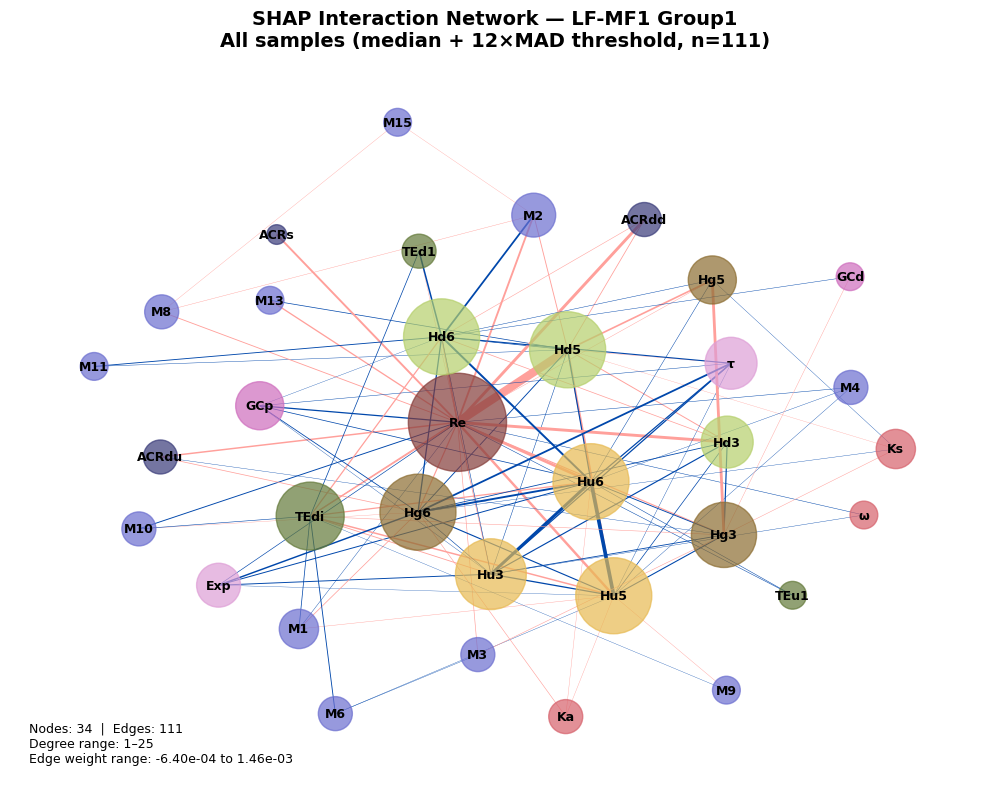


  --- Dominant ---
    Total pairs          : 946
    Non-zero pairs       : 926
    Pairs above threshold: 115
    Saved edge tables: lf_mf1_groupI_interaction_label0_*.csv
    Saved degree table: lf_mf1_groupI_interaction_label0_node_degrees.csv
  Nodes: 34  |  Edges: 115  |  Degree range: 1–25
  Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_network/lf_mf1_groupI_interaction_label0_network.png


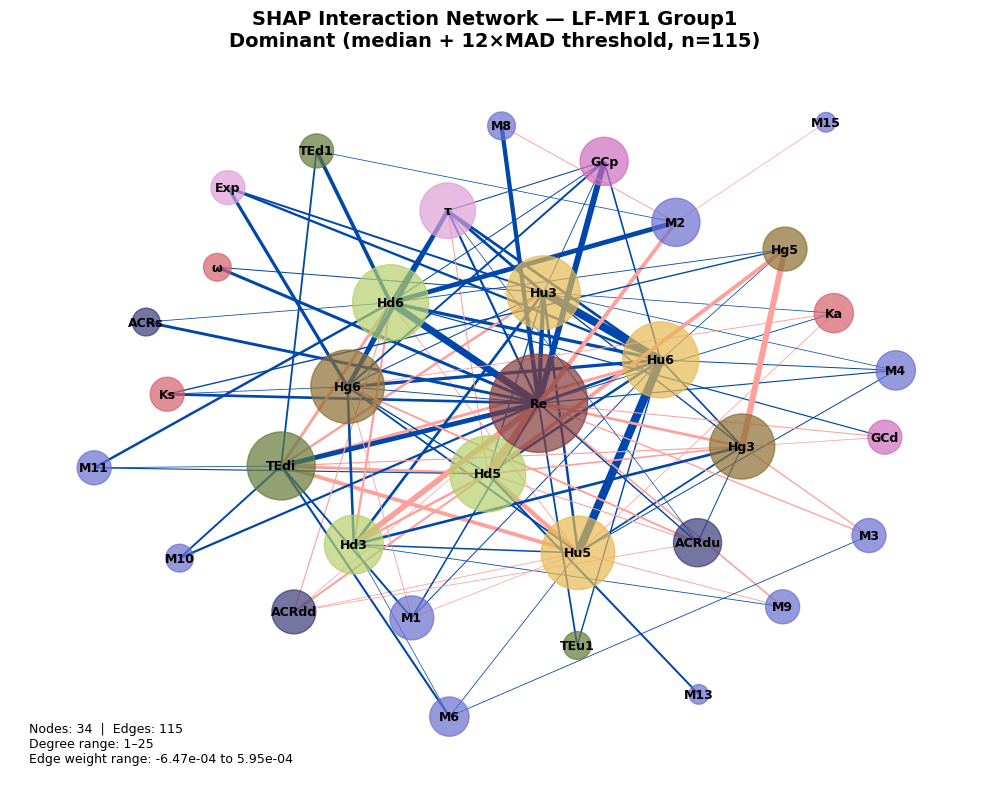


  --- Non-dominant ---
    Total pairs          : 946
    Non-zero pairs       : 926
    Pairs above threshold: 124
    Saved edge tables: lf_mf1_groupI_interaction_label1_*.csv
    Saved degree table: lf_mf1_groupI_interaction_label1_node_degrees.csv
  Nodes: 37  |  Edges: 124  |  Degree range: 1–30
  Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_network/lf_mf1_groupI_interaction_label1_network.png


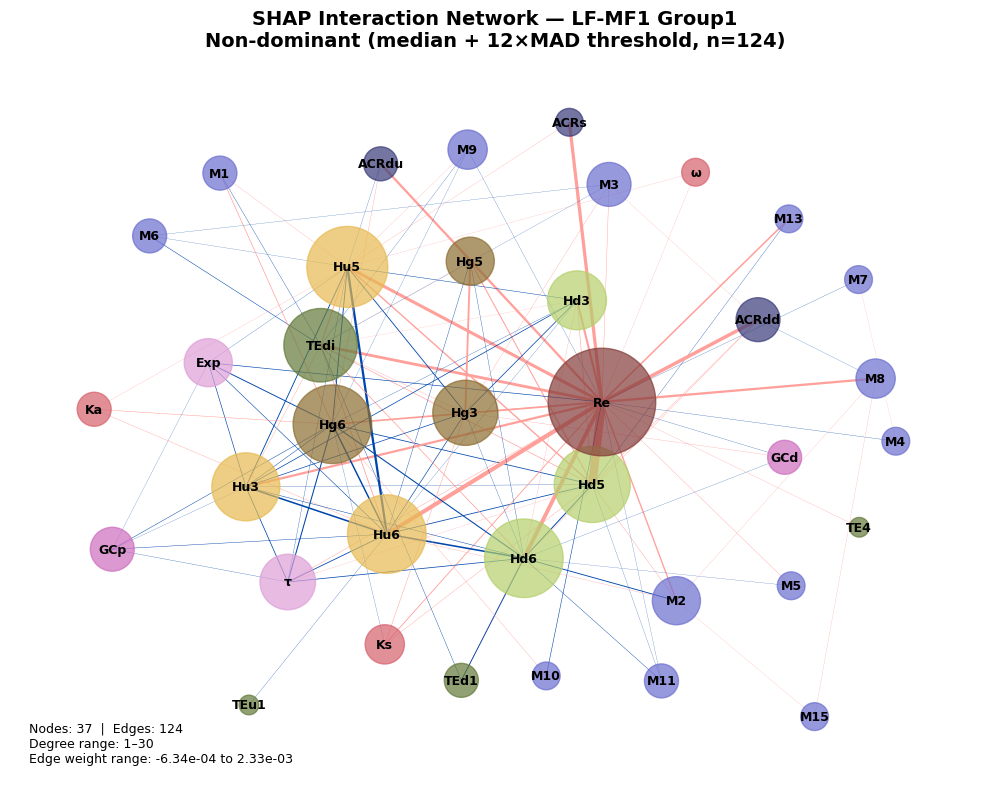


Group LF-MF2_g1 (LF-MF2 Group1)
  Threshold computation (all-samples, non-zero pairs):
    Total pairs     : 946
    Non-zero pairs  : 946 (100.0%)
    Median          : 0.00000716
    MAD             : 0.00000633
    K_INTERACTION   : 12
    Threshold       : 0.00008311
    Saved diagnostics: /blue/meixiazhao/laylaaschuster/brapaGDM/final_network/lf_mf2_groupI_interaction_threshold_diagnostics.csv

  --- All samples ---
    Total pairs          : 946
    Non-zero pairs       : 946
    Pairs above threshold: 95
    Saved edge tables: lf_mf2_groupI_interaction_all_*.csv
    Saved degree table: lf_mf2_groupI_interaction_all_node_degrees.csv
  Nodes: 38  |  Edges: 95  |  Degree range: 1–25
  Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_network/lf_mf2_groupI_interaction_all_network.png


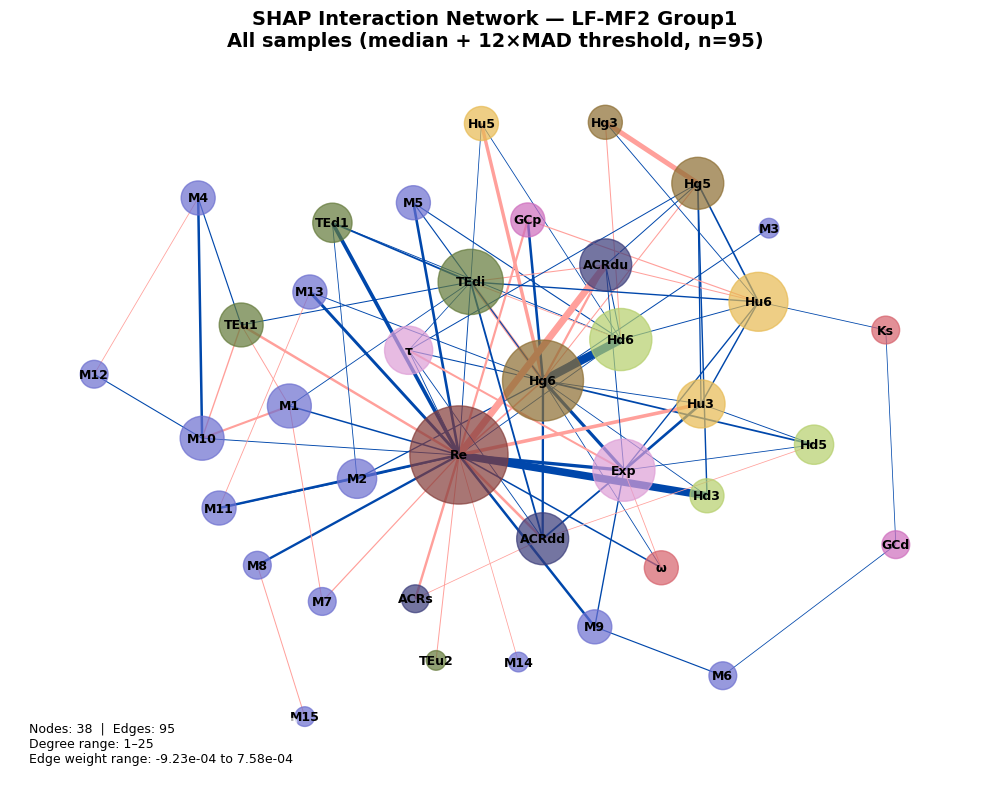


  --- Dominant ---
    Total pairs          : 946
    Non-zero pairs       : 946
    Pairs above threshold: 96
    Saved edge tables: lf_mf2_groupI_interaction_label0_*.csv
    Saved degree table: lf_mf2_groupI_interaction_label0_node_degrees.csv
  Nodes: 37  |  Edges: 96  |  Degree range: 1–27
  Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_network/lf_mf2_groupI_interaction_label0_network.png


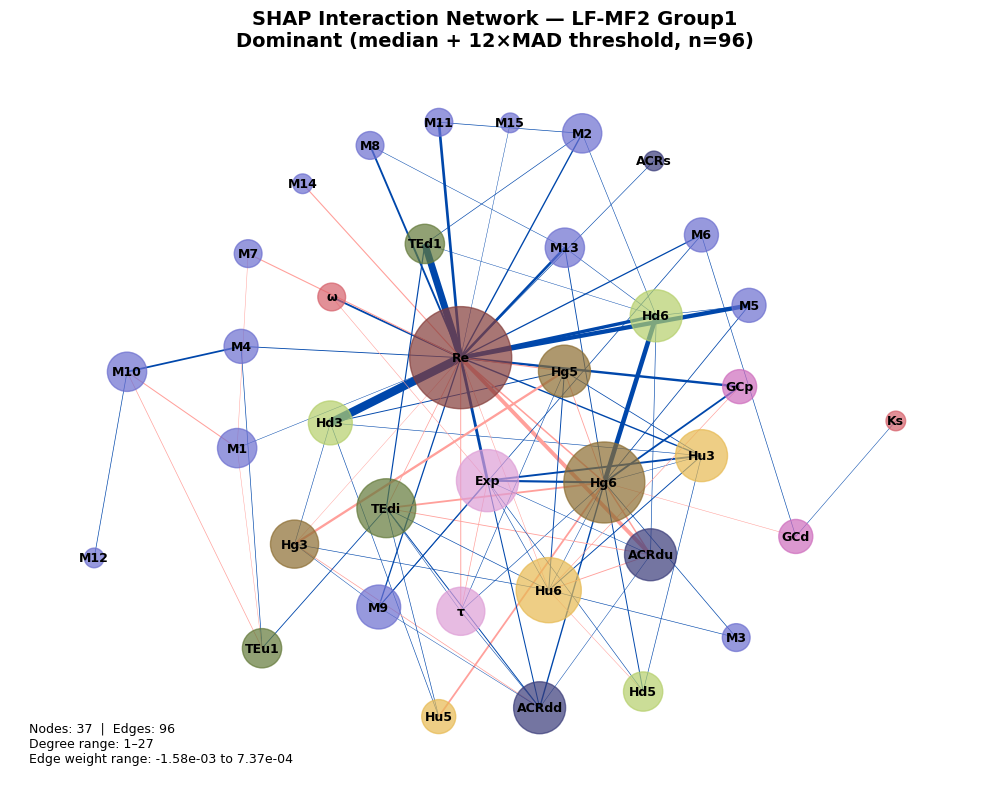


  --- Non-dominant ---
    Total pairs          : 946
    Non-zero pairs       : 946
    Pairs above threshold: 94
    Saved edge tables: lf_mf2_groupI_interaction_label1_*.csv
    Saved degree table: lf_mf2_groupI_interaction_label1_node_degrees.csv
  Nodes: 38  |  Edges: 94  |  Degree range: 1–25
  Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_network/lf_mf2_groupI_interaction_label1_network.png


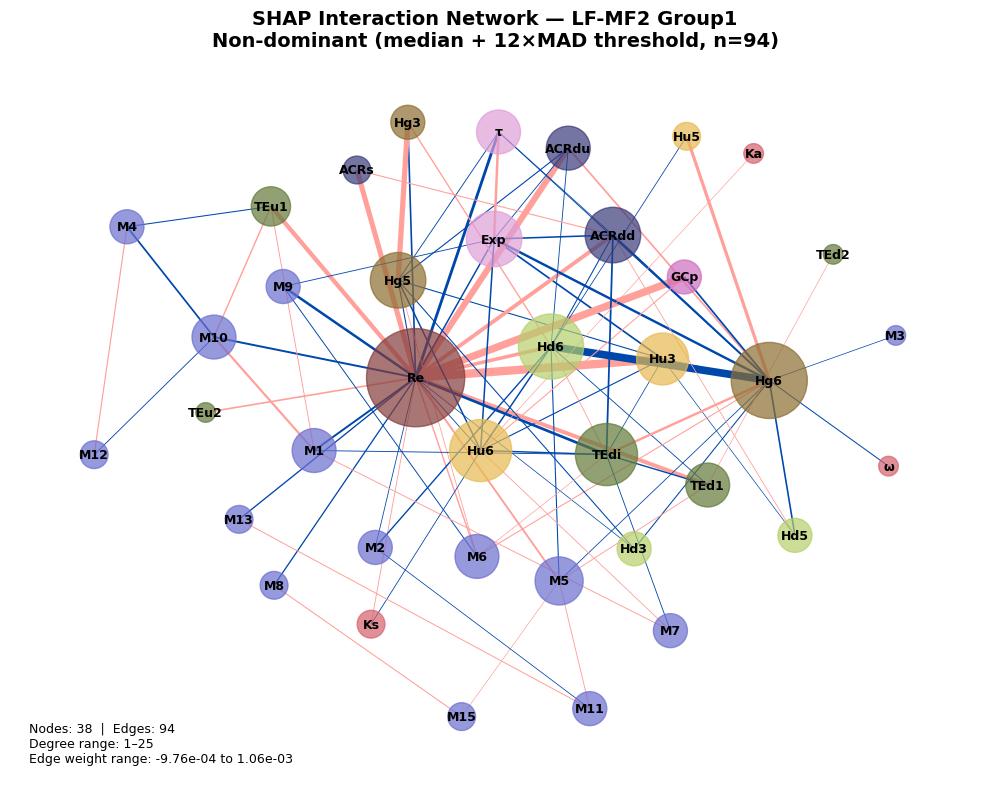


Group MF1-MF2_g1 (MF1-MF2 Group1)
  Threshold computation (all-samples, non-zero pairs):
    Total pairs     : 946
    Non-zero pairs  : 445 (47.0%)
    Median          : 0.00000200
    MAD             : 0.00000164
    K_INTERACTION   : 12
    Threshold       : 0.00002168
    Saved diagnostics: /blue/meixiazhao/laylaaschuster/brapaGDM/final_network/mf1_mf2_groupI_interaction_threshold_diagnostics.csv

  --- All samples ---
    Total pairs          : 946
    Non-zero pairs       : 445
    Pairs above threshold: 43
    Saved edge tables: mf1_mf2_groupI_interaction_all_*.csv
    Saved degree table: mf1_mf2_groupI_interaction_all_node_degrees.csv
  Nodes: 29  |  Edges: 43  |  Degree range: 1–22
  Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_network/mf1_mf2_groupI_interaction_all_network.png


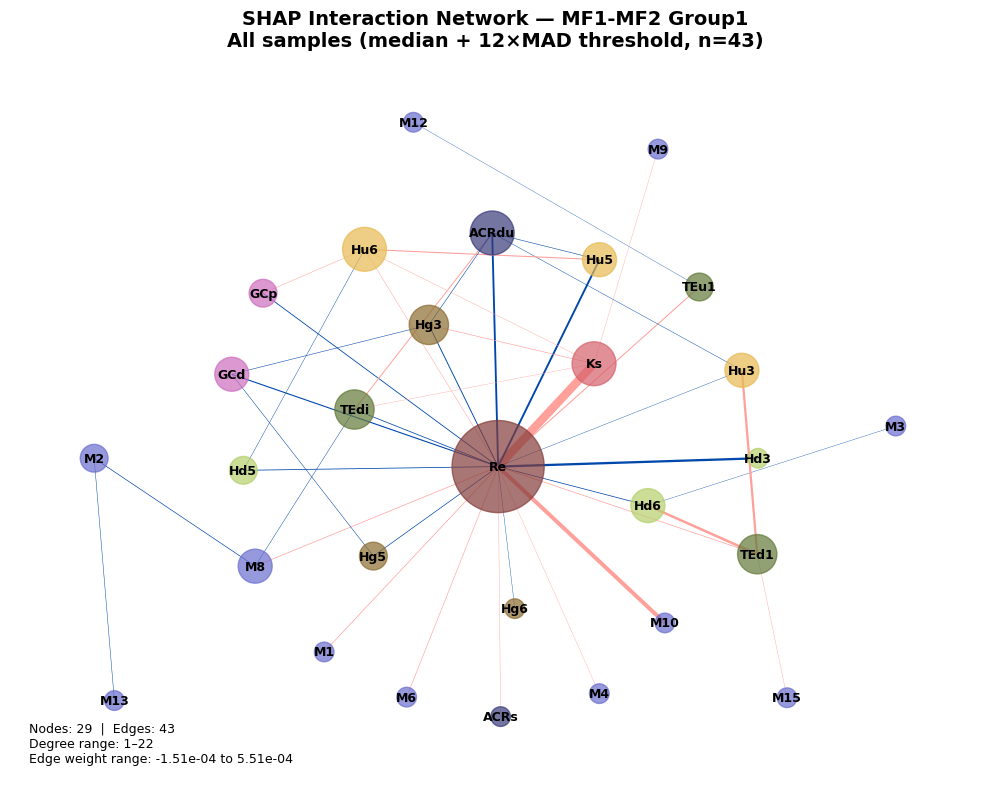


  --- Dominant ---
    Total pairs          : 946
    Non-zero pairs       : 445
    Pairs above threshold: 52
    Saved edge tables: mf1_mf2_groupI_interaction_label0_*.csv
    Saved degree table: mf1_mf2_groupI_interaction_label0_node_degrees.csv
  Nodes: 34  |  Edges: 52  |  Degree range: 1–30
  Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_network/mf1_mf2_groupI_interaction_label0_network.png


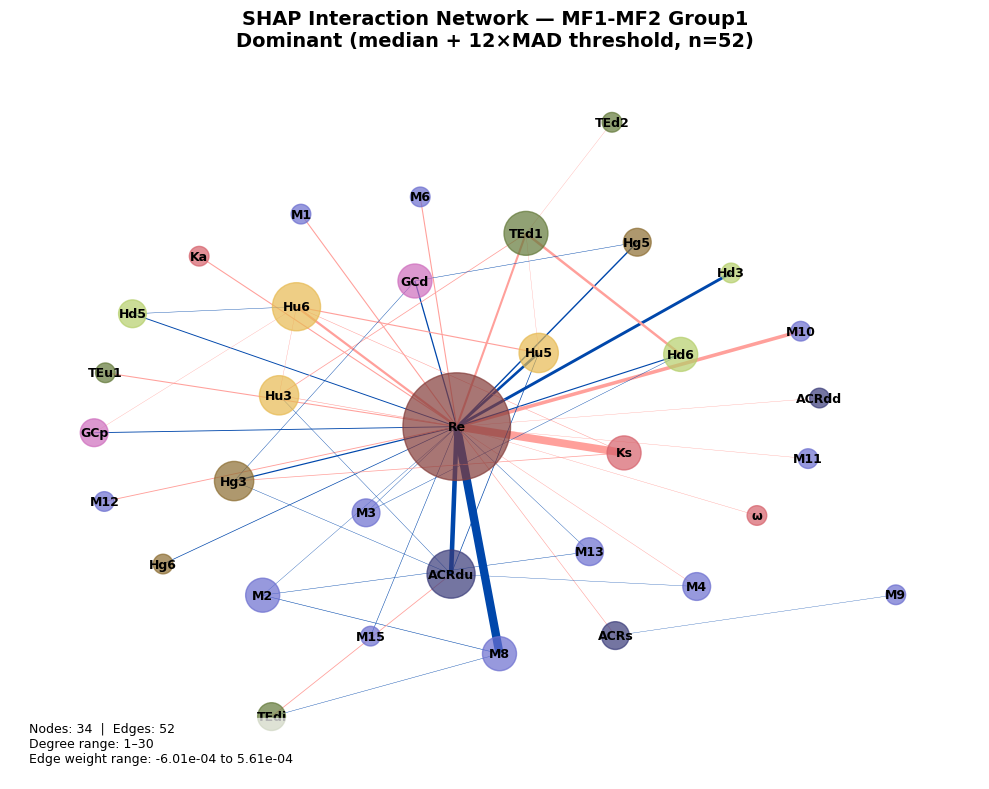


  --- Non-dominant ---
    Total pairs          : 946
    Non-zero pairs       : 445
    Pairs above threshold: 43
    Saved edge tables: mf1_mf2_groupI_interaction_label1_*.csv
    Saved degree table: mf1_mf2_groupI_interaction_label1_node_degrees.csv
  Nodes: 26  |  Edges: 43  |  Degree range: 1–20
  Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_network/mf1_mf2_groupI_interaction_label1_network.png


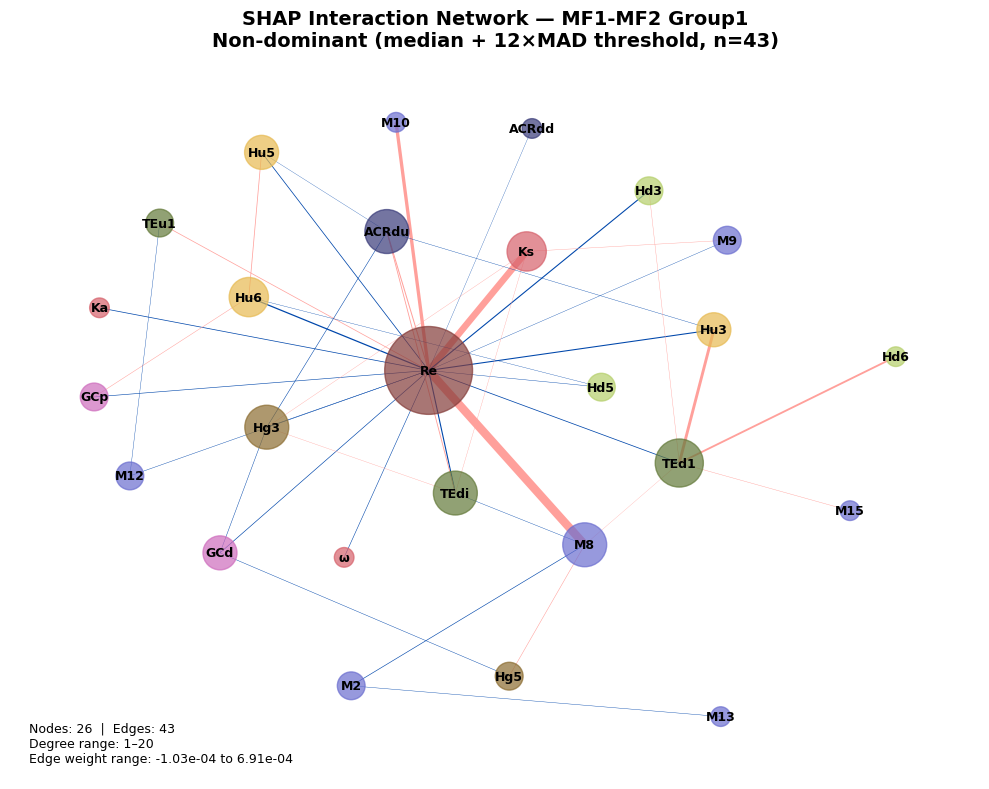


Saved combined threshold diagnostics: /blue/meixiazhao/laylaaschuster/brapaGDM/final_network/interaction_threshold_diagnostics_all_groups_groupI.csv


In [27]:
# ============================================================
# INDIVIDUAL NETWORK PLOTS — INTERACTION METHOD
# ============================================================
# Constructs and plots Shapley interaction networks for all
# 3 groups × 3 label subsets (all / dominant / non-dominant),
# giving 9 individual networks total.
#
# For each group:
#   1. The group-specific threshold is computed ONCE from
#      the all-samples interaction array using
#      compute_interaction_threshold() at K_INTERACTION=12.
#   2. That same threshold is applied to all three label
#      subsets — ensuring subgenome comparisons are not
#      confounded by different noise floors.
#   3. Retained pairs become edges; edge weight is the
#      signed mean interaction value for that subset.
#   4. build_network_and_layout() and plot_single_network()
#      are reused from the co-variation network section.
#
# Threshold diagnostics are printed and saved per group
# for methods reporting. All edge tables are saved including
# the full all_edges table (not just significant) for
# supplemental reference.
# ============================================================

INTERACTION_LABELS = {
    group: [
        ("all",    "shap_interaction_all",    "All samples"),
        ("label0", "shap_interaction_label0", "Dominant"),
        ("label1", "shap_interaction_label1", "Non-dominant"),
    ] for group in GROUPS
}

interaction_network_data = {
    group: {} for group in GROUPS
}

threshold_diagnostics_all = {}

for group in GROUPS:
    print(f"\n{'='*60}")
    print(f"Group {group} ({GROUP_LABELS[group]})")
    print(f"{'='*60}")

    interaction_array_all = shap_data[group]["shap_interaction_all"]
    feat_labels           = feature_names[group]

    threshold, diagnostics = compute_interaction_threshold(
        interaction_array_all = interaction_array_all,
        feature_labels        = feat_labels,
        k                     = K_INTERACTION,
    )
    threshold_diagnostics_all[group] = diagnostics

    print(f"  Threshold computation (all-samples, non-zero pairs):")
    print(f"    Total pairs     : {diagnostics['n_total_pairs']:,}")
    print(f"    Non-zero pairs  : {diagnostics['n_nonzero']:,} "
          f"({diagnostics['pct_nonzero']:.1f}%)")
    print(f"    Median          : {diagnostics['median']:.8f}")
    print(f"    MAD             : {diagnostics['mad']:.8f}")
    print(f"    K_INTERACTION   : {K_INTERACTION}")
    print(f"    Threshold       : {threshold:.8f}")

    diag_path = os.path.join(
        NETWORK_DIR,
        f"{PREFIXES[group]}_interaction_threshold_diagnostics.csv"
    )
    pd.DataFrame([diagnostics]).to_csv(diag_path, index=False)
    print(f"    Saved diagnostics: {diag_path}")

    # --- Apply threshold to all three label subsets ---
    # INTERACTION_LABELS[group] gives the correct subgenome
    # display name for each label subset of this group.
    for label_key, data_key, label_display in INTERACTION_LABELS[group]:
        print(f"\n  --- {label_display} ---")

        interaction_array = shap_data[group][data_key]

        sig_edges, all_edges = compute_interaction_significance(
            interaction_array = interaction_array,
            feature_labels    = feat_labels,
            threshold         = threshold,
        )

        n_total    = len(all_edges)
        n_nonzero  = (all_edges["abs_weight"] > 0).sum()
        n_retained = len(sig_edges)
        print(f"    Total pairs          : {n_total:,}")
        print(f"    Non-zero pairs       : {n_nonzero:,}")
        print(f"    Pairs above threshold: {n_retained:,}")

        suffix = f"_interaction_{label_key}"
        
        all_edges_path = os.path.join(
            NETWORK_DIR,
            f"{PREFIXES[group]}{suffix}_all_edges.csv"
        )
        sig_edges_path = os.path.join(
            NETWORK_DIR,
            f"{PREFIXES[group]}{suffix}_significant_edges.csv"
        )
        
        all_edges.assign(
            source=all_edges['source'].map(feature_rename_dict).fillna(all_edges['source']),
            target=all_edges['target'].map(feature_rename_dict).fillna(all_edges['target'])
        ).to_csv(all_edges_path, index=False)

        sig_edges.assign(
            source=sig_edges['source'].map(feature_rename_dict).fillna(sig_edges['source']),
            target=sig_edges['target'].map(feature_rename_dict).fillna(sig_edges['target'])
        ).to_csv(sig_edges_path, index=False)
    
        print(f"    Saved edge tables: {PREFIXES[group]}{suffix}_*.csv")

        Gx, layout = build_network_and_layout(sig_edges)

        if Gx.number_of_nodes() > 0:
            degree_df = pd.DataFrame(
                Gx.degree, columns=["node", "degree"]
            ).sort_values(
                by="degree", ascending=False
            ).reset_index(drop=True)
            degree_path = os.path.join(
                NETWORK_DIR,
                f"{PREFIXES[group]}{suffix}_node_degrees.csv"
            )
            degree_df.assign(
                node=degree_df['node'].map(feature_rename_dict).fillna(degree_df['node'])
            ).to_csv(degree_path, index=False)
            print(f"    Saved degree table: "
                  f"{PREFIXES[group]}{suffix}_node_degrees.csv")

        interaction_network_data[group][label_key] = {
            "Gx"       : Gx,
            "layout"   : layout,
            "sig_edges": sig_edges,
        }

        plot_single_network(
            Gx                  = Gx,
            layout              = layout,
            title               = (
                f"SHAP Interaction Network — {GROUP_LABELS[group]}\n"
                f"{label_display} "
                f"(median + {K_INTERACTION}×MAD threshold, "
                f"n={n_retained})"
            ),
            save_path           = os.path.join(
                NETWORK_DIR,
                f"{PREFIXES[group]}{suffix}_network.png"
            ),
            feature_rename_dict = feature_rename_dict,
            feature_to_group    = feature_to_group,
            group_to_color      = group_to_color,
        )

# --- Save combined threshold diagnostics table ---
diag_combined_path = os.path.join(
    NETWORK_DIR, f"interaction_threshold_diagnostics_all_groups_{COMBINED_SUFFIX}.csv"
)
pd.DataFrame(threshold_diagnostics_all).T.to_csv(diag_combined_path)
print(f"\nSaved combined threshold diagnostics: {diag_combined_path}")

### Combined Interaction Networks

Global max abs edge weight (all-samples figure): 0.001460
Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_network/combined_interaction_groupI.png


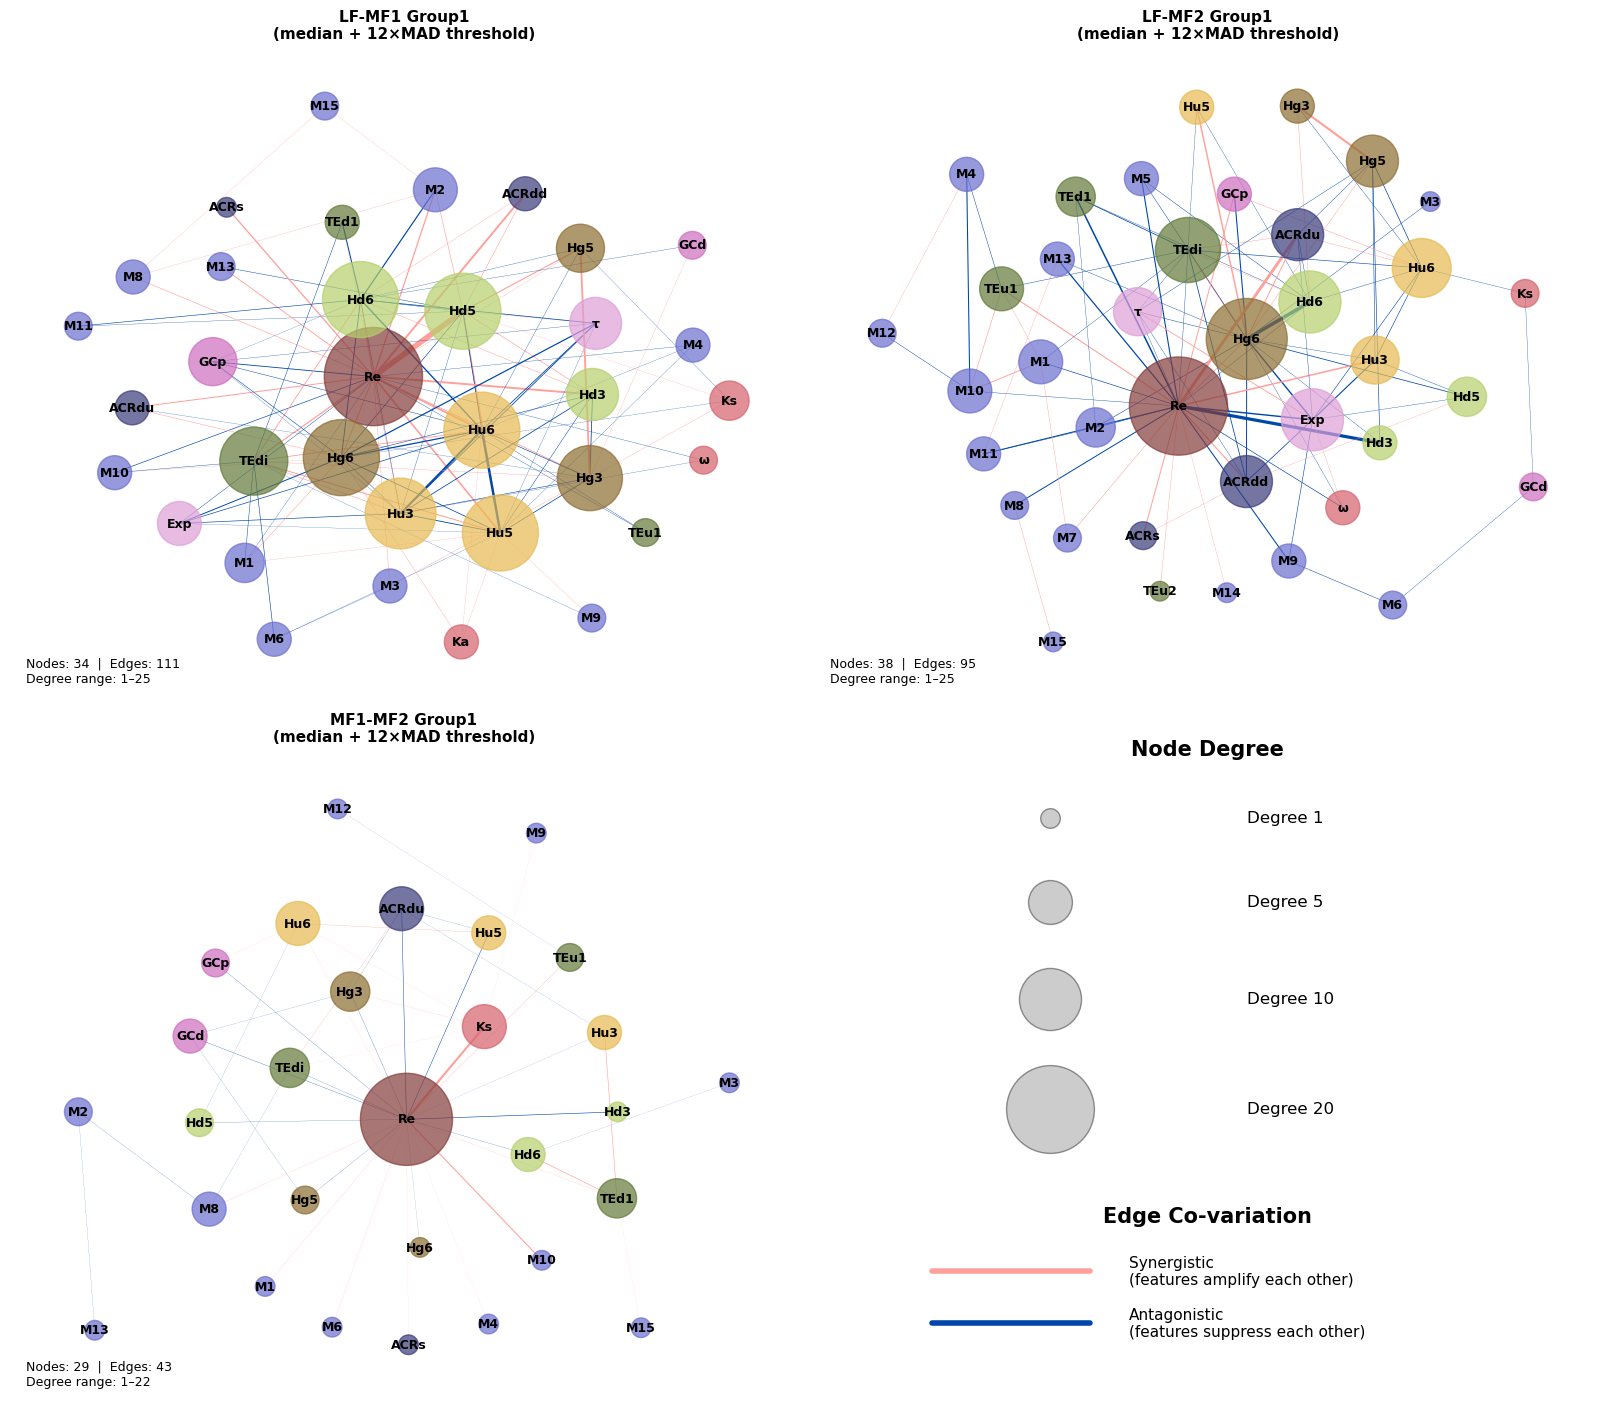

In [28]:
# --- Calls ---
# K_INTERACTION is passed explicitly to both functions so
# that panel titles and empty-network annotations reflect
# the parameter value without hardcoding it in the functions.

plot_interaction_combined_all(
    interaction_network_data = interaction_network_data,
    group_labels             = GROUP_LABELS,
    feature_rename_dict      = feature_rename_dict,
    feature_to_group         = feature_to_group,
    group_to_color           = group_to_color,
    save_path                = os.path.join(
        NETWORK_DIR, f"combined_interaction_{COMBINED_SUFFIX}.png"
    ),
    k_interaction            = K_INTERACTION,
)


### Combined Interaction Networks by Label

Global max abs edge weight (label comparison figure): 0.002325
Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_network/combined_interaction_label_groupI.png


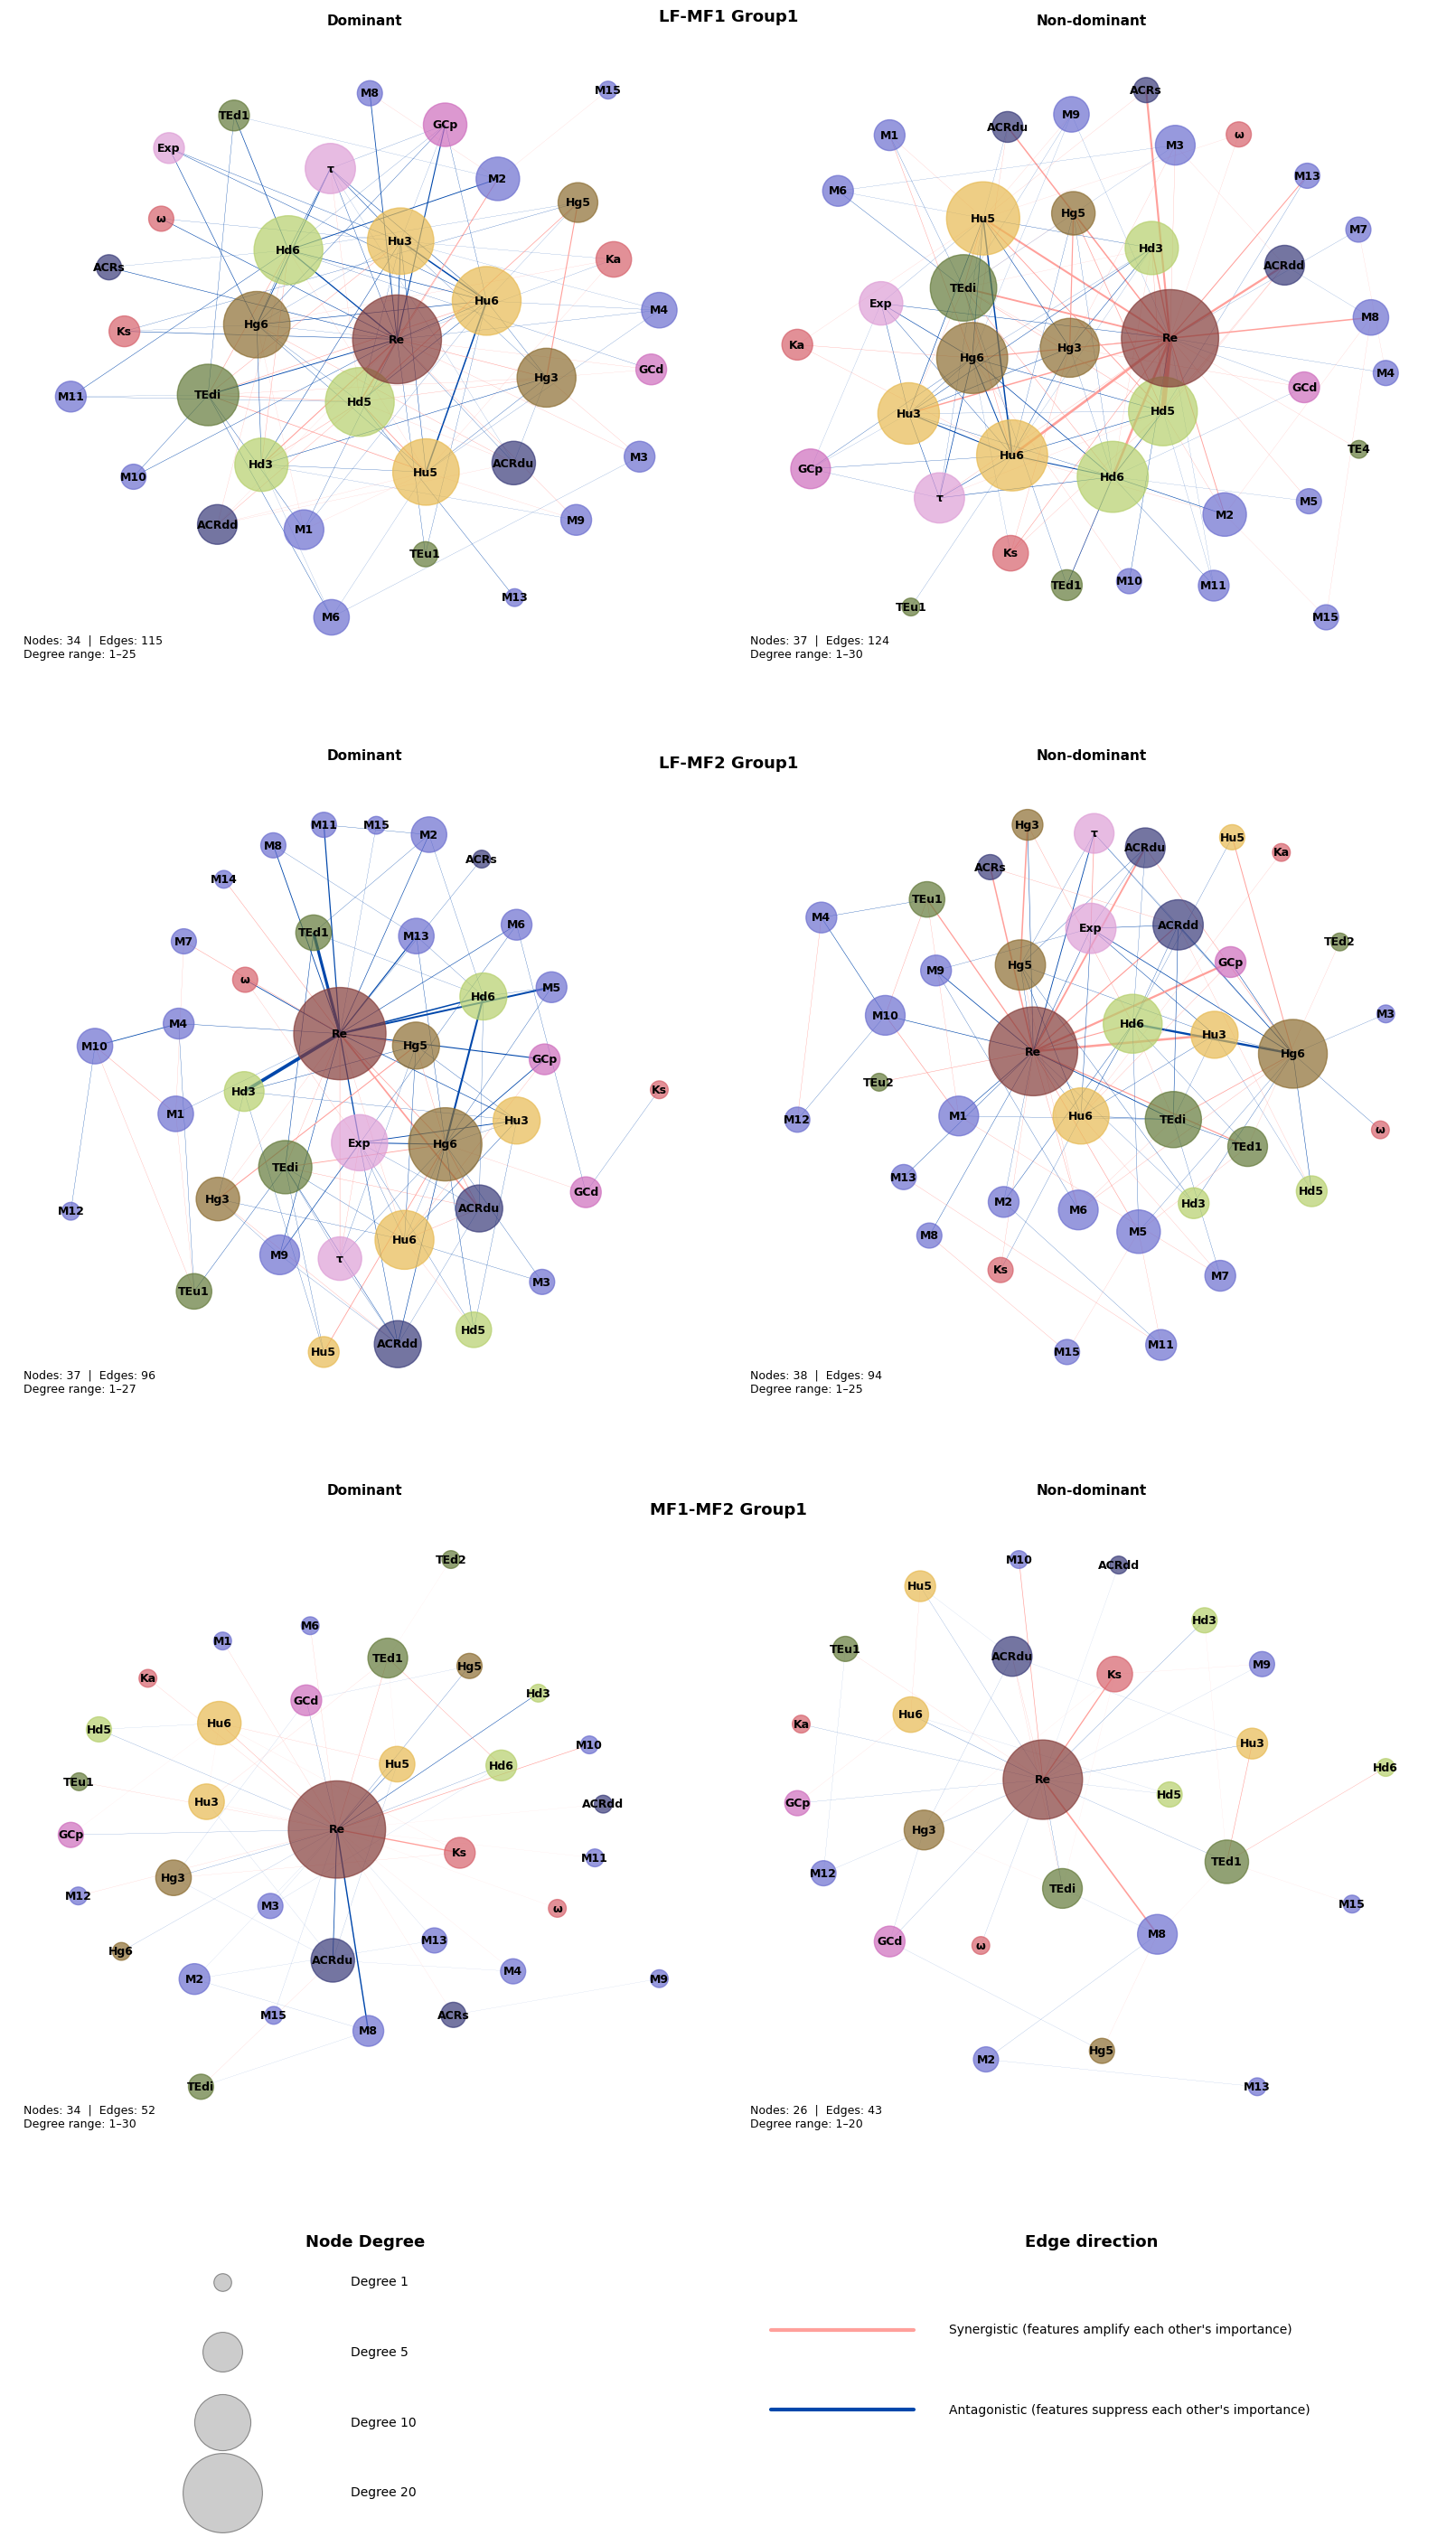

In [29]:
plot_interaction_combined_label(
    interaction_network_data = interaction_network_data,
    group_labels             = GROUP_LABELS,
    interaction_labels       = INTERACTION_LABELS, 
    feature_rename_dict      = feature_rename_dict,
    feature_to_group         = feature_to_group,
    group_to_color           = group_to_color,
    save_path                = os.path.join(
        NETWORK_DIR, f"combined_interaction_label_{COMBINED_SUFFIX}.png"
    ),
    k_interaction            = K_INTERACTION,
)

## Interaction Heatmaps

In [30]:
# ============================================================
# INTERACTION HEATMAPS — ALL 15
# ============================================================
# For each group × label subset (all / label0 / label1),
# computes the mean Shapley interaction value across samples
# for each feature pair and plots a clustered heatmap.
#
# METHODS NOTE:
# The diagonal is set to zero before plotting — main effects
# (diagonal entries) are orders of magnitude larger than
# off-diagonal interaction terms and would compress the
# colorscale, obscuring the interaction signal of interest.
# Features are clustered using Ward linkage with Euclidean
# distance, computed independently per heatmap so that each
# group's interaction structure determines its own feature
# ordering. The colorscale is symmetric around zero
# (vmin = -abs_max, vmax = abs_max): red = synergistic
# interaction (positive mean φ_jk), blue = antagonistic
# (negative mean φ_jk).
#
# These heatmaps are complementary to the interaction network
# figures and show the full pairwise interaction landscape
# regardless of the effect size threshold applied to the
# networks. The networks retain only pairs whose absolute
# mean interaction exceeds the group-specific robust
# threshold (median + K_INTERACTION × MAD of non-zero
# all-samples pairs). The heatmaps intentionally include
# all pairs — including those below the threshold — so that
# the global structure of feature relationships within each
# group is visible and the threshold decision can be
# visually evaluated by the reader.
#
# Resolution is 300 dpi (sufficient for heatmaps; 15 files
# at 600 dpi would be prohibitively large).
# ============================================================
def plot_interaction_heatmap(
    interaction_array,
    feature_labels,
    feature_rename_dict,
    title,
    save_path,
):
    """
    Plot a clustered heatmap of mean Shapley interaction values
    for one group × label subset combination.

    Averages the 3D interaction array across samples to produce
    a (n_features × n_features) mean interaction matrix, zeros
    the diagonal to suppress main effects, renames features to
    short display names, then calls plot_clustered_heatmap().

    All feature pairs are included regardless of whether they
    exceed the effect size threshold used in the network
    figures (median + K_INTERACTION × MAD). These heatmaps
    show the full interaction landscape so that the threshold
    decision can be evaluated in context. See
    compute_interaction_threshold() for threshold derivation.

    Parameters
    ----------
    interaction_array : np.ndarray, shape
                        (n_samples, n_features, n_features)
        Shapley interaction values for one group and label
        subset. Can be shap_interaction_all,
        shap_interaction_label0, or shap_interaction_label1.
    feature_labels    : list of str
        Original feature names corresponding to array axes
        1 and 2. Used for renaming via feature_rename_dict.
    feature_rename_dict : dict
        Maps original feature name -> short display name.
        Names not in the dict are displayed as-is.
    title             : str
        Panel title displayed above the heatmap.
    save_path         : str
        Full path for the saved .png file.
    """
    mean_matrix = interaction_array.mean(axis=0)
    np.fill_diagonal(mean_matrix, 0)
    short_labels = [feature_rename_dict.get(f, f) for f in feature_labels]
    matrix_df = pd.DataFrame(
        mean_matrix,
        index   = short_labels,
        columns = short_labels,
    )
    plot_clustered_heatmap(
        matrix_df      = matrix_df,
        title          = title,
        save_path      = save_path,
        colorbar_label = 'Mean Shapley interaction value',
    )

In [31]:
# ============================================================
# RUN INTERACTION HEATMAPS — ALL 9
# ============================================================
# Generates one heatmap per group × label subset combination:
#   3 groups (LF-MF1, LF-MF2, MF1-MF2)
#   × 3 label subsets (all samples, dominant, non-dominant)
#   = 9 heatmaps total
#
# Each heatmap shows the full pairwise mean Shapley interaction
# landscape for that group and label subset, including all
# pairs regardless of whether they exceed the effect size
# threshold used in the network figures. See the methods note
# in plot_interaction_heatmap() for full discussion.
#
# Titles include the label subset so each saved file is
# self-identifying when reviewed alongside the network figures.
# Resolution is 300 dpi — sufficient for heatmaps and keeps
# file sizes manageable across 9 outputs.
# ============================================================

from unittest.mock import patch

with patch('matplotlib.pyplot.show'):
    for group in GROUPS:
        for label_key, data_key, label_display in INTERACTION_LABELS[group]:
            print(f"\n--- Group {group} ({GROUP_LABELS[group]}) "
                  f"— {label_display} ---")

            plot_interaction_heatmap(
                interaction_array   = shap_data[group][data_key],
                feature_labels      = feature_names[group],
                feature_rename_dict = feature_rename_dict,
                title               = (
                    f"SHAP Interaction Heatmap — {GROUP_LABELS[group]}\n"
                    f"{label_display}"
                ),
                save_path           = os.path.join(
                    NETWORK_DIR,
                    f"{PREFIXES[group]}_interaction_{label_key}_heatmap.png"
                ),
            )


--- Group LF-MF1_g1 (LF-MF1 Group1) — All samples ---
  Dendrogram symmetry confirmed.
  Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_network/lf_mf1_groupI_interaction_all_heatmap.png

--- Group LF-MF1_g1 (LF-MF1 Group1) — Dominant ---
  Dendrogram symmetry confirmed.
  Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_network/lf_mf1_groupI_interaction_label0_heatmap.png

--- Group LF-MF1_g1 (LF-MF1 Group1) — Non-dominant ---
  Dendrogram symmetry confirmed.
  Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_network/lf_mf1_groupI_interaction_label1_heatmap.png

--- Group LF-MF2_g1 (LF-MF2 Group1) — All samples ---
  Dendrogram symmetry confirmed.
  Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_network/lf_mf2_groupI_interaction_all_heatmap.png

--- Group LF-MF2_g1 (LF-MF2 Group1) — Dominant ---
  Dendrogram symmetry confirmed.
  Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_network/lf_mf2_groupI_interaction_label0_heatmap.png

--- Group LF-MF2_g1 (LF-M